## Setup for LSTM

In [52]:
#pip install --upgrade pip
#%pip install keras
#%pip install tensorflow 

In [53]:
#%pip install keras

In [54]:
 #%pip install tensorflow 

In [4]:
# Importing required libraries
import requests
import pandas as pd
import csv
import numpy as np
from itertools import permutations

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from statsmodels.tsa.seasonal import seasonal_decompose
# this for time series
#import statsmodels.formula.api as smf
#from statsmodels.tsa.seasonal import seasonal_decompose
#from scipy.ndimage import gaussian_filter
#from calendar import monthrange
#from calendar import month_name
#from sklearn.metrics import mean_squared_error
#from math import sqrt
#from statsmodels.tsa.stattools import adfuller,kpss
#from statsmodels.tsa.seasonal import seasonal_decompose
#from statsmodels.tsa.arima_model import ARIMA
#from statsmodels.graphics.tsaplots import plot_pacf
#from pmdarima.arima import auto_arima
#import statsmodels.graphics.tsaplots as tsaplot
#from statsmodels.tsa.holtwinters import Holt, ExponentialSmoothing, SimpleExpSmoothing

#import tensorflow as tf
#from keras.models import Sequential
#from keras.layers import LSTM, Dense
#import matplotlib.dates as mdates   
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.models import load_model

#from keras.optimizers import Adam
#from keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
#from keras.optimizers import Adam
import time
from tensorflow.keras.regularizers import l1, l2
import matplotlib.dates as mdates   


### Columns
|Name                | Description                                                                   | Type     |Energy Source
|---------------------|-------------------------------------------------------------------------------|----------|----------|
| Area       |     Whole Germany                          |object   |     |
| Mtu     |                                  | object  |    |
| Biomass_mwh         |     Biomass                 | float64 |Renewable |
| Fossil_brown_coal_mwh      | Fossil brown coal              | float64 |Fossil  Fuels|
| Fossil_coal_derived_gas_mwh    |    Fossil coal derived gas       | float64 |Fossil  Fuels |
| Fossil_gas_mwh      |      Fossil gas                | float64 |Fossil  Fuels|
| Fossil_hard_coal_mwh     |      Fossil hard coal           | float64 |Fossil  Fuels|
| Fossil_oil_mwh      |       Fossil oil               | float64 |Fossil  Fuels|
| Fossil_oil_shale_mwh     |    Fossil oil shale             | float64 |Fossil  Fuels   |
| Fossil_peat_mwh     |   Fossil peat                    | float64 |Fossil  Fuels |
| Geothermal_mwh    |        Geothermal                | float64 |Renewable|
| Hydro_pumped_storage_aggregated_mwh  | Hydro pumped storage (generation)    | float64 |    |
| Hydro_pumped_storage_consumption_mwh   | Hydro pumped storage (consumption)| float64 |    |
| Hydro_run_of_river_and_poundage_mwh   | Hydro run of river and poundage   | float64 |Renewable|
| Hydro_water_reservoir_mwh  |    Hydro water reservoir             | float64 |Renewable|
| Marine_mwh     |   Marine                        | float64 |Renewable|
| Nuclear_mwh  |       Nuclear                       | float64 |Nuclear   |
| Other_mwh     |       Other                     | float64 |    |
| Other_renewable_mwh     |    Other renewable              | float64 |Renewable|
| Solar_mwh     |      Solar                      | float64 |Renewable |
| Waste_mwh    |     Waste                        | float64 |Renewable  |
| Wind_offshore_mwh    |  Wind offshore                   | float6  |Renewable |
| Wind_onshore_mwh   |      Wind onshore                 | float64 |Renewable  |
| Date                  |   Date(yyyy-mm-dd)                 | int64 |    |
| Hour        |Timesatmp of 'UTC+1' timezone                          | int64 |    |
| Total_energy_generation_mwh   | Total energy generation of Germany           | float64 |    |
| Total_other_renewable_mwh   | Total renewable energy generation (excluding solar)  of Germany           | float64 |    |


m#### Dataframes details 
- res_df $\rightarrow$  Import  the original  data
- data_df_mwh  $\rightarrow$   Data in mwh units (This copy of original data)
- data_df_gwh  $\rightarrow$  Data in gwh units 
- data_df  $\rightarrow$  Contain the final preprocessing data in mwh/gwh units 

### Units of Solar Energy production
- One kilowatt (kW) =  1,000 watts, 
- One megawatt (MW) =  1,000 kilowatts, 
- One gigawatt (GW) =  1,000 megawatts, 
- One terawatt (TW) =  1,000 gigawatts.

In [56]:
# Target columns   total_energy_generation_mwh, solar_mwh

In [57]:
# Import data
#This is data file of 20.07.2023
#res_df = pd.read_csv('data/result_20150101-20230716_cond2.csv')
# This is updated data file of 24.07.2023
res_df = pd.read_csv('data/transparency_20150101-20230716_hourly.csv')
res_df.head()

,area,mtu,biomass_mwh,fossil_brown_coal_mwh,fossil_coal_derived_gas_mwh,fossil_gas_mwh,fossil_hard_coal_mwh,fossil_oil_mwh,fossil_oil_shale_mwh,fossil_peat_mwh,...,nuclear_mwh,other_mwh,other_renewable_mwh,solar_mwh,waste_mwh,wind_offshore_mwh,wind_onshore_mwh,date,hour,total_energy_generation_mwh
0,Germany (DE),20150101 00:00-01:00,3997.50,15687.25,0.0,1226.25,3219.75,176.50,0.0,0.0,...,10710.50,4567.50,123.0,0.0,298.25,521.00,8849.75,20150101,0,51459.25
1,Germany (DE),20150101 01:00-02:00,3956.50,15321.75,0.0,870.75,2351.25,174.50,0.0,0.0,...,11086.25,4596.25,112.5,0.0,295.00,520.75,9046.50,20150101,1,49988.25
2,Germany (DE),20150101 02:00-03:00,3991.75,14817.50,0.0,809.50,2227.00,172.75,0.0,0.0,...,11026.25,4713.75,83.0,0.0,288.25,519.00,9196.00,20150101,2,49265.25
3,Germany (DE),20150101 03:00-04:00,4009.75,14075.00,0.0,821.00,2339.75,173.25,0.0,0.0,...,11027.75,4740.25,76.0,0.0,303.50,522.50,9146.75,20150101,3,48538.00
4,Germany (DE),20150101 04:00-05:00,4006.00,14115.00,0.0,831.25,2461.50,174.25,0.0,0.0,...,10962.25,4726.50,76.0,0.0,303.00,524.25,9204.00,20150101,4,48630.00


In [58]:
#res_df.dtypes

In [59]:
res_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74879 entries, 0 to 74878
Data columns (total 26 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   area                                  74879 non-null  object 
 1   mtu                                   74879 non-null  object 
 2   biomass_mwh                           74879 non-null  float64
 3   fossil_brown_coal_mwh                 74879 non-null  float64
 4   fossil_coal_derived_gas_mwh           74879 non-null  float64
 5   fossil_gas_mwh                        74879 non-null  float64
 6   fossil_hard_coal_mwh                  74879 non-null  float64
 7   fossil_oil_mwh                        74879 non-null  float64
 8   fossil_oil_shale_mwh                  74879 non-null  float64
 9   fossil_peat_mwh                       74879 non-null  float64
 10  geothermal_mwh                        74879 non-null  float64
 11  hydro_pumped_st

In [60]:
# Cerate a working data frame
#importing data in original units 
data_df_mwh = res_df.copy()
#data_df_mwh.head()

In [61]:
#ycol_all_renw = ['total_energy_generation_mwh', 'solar_mwh', 'solar/energy_total','diff_total_energy_and_solar_mwh',
#             'wind_onshore_mwh','wind_offshore_mwh','waste_mwh','Solar_mwh','other_renewable_mwh',  
#             'marine_mwh','hydro_run_of_river_and_poundage_mwh','hydro_water_reservoir_mwh','geothermal_mwh']
#
#ycol_renw = ['wind_onshore_mwh','wind_offshore_mwh','waste_mwh','other_renewable_mwh',  
#             'marine_mwh','hydro_run_of_river_and_poundage_mwh','hydro_water_reservoir_mwh','geothermal_mwh']


#### Here we add new columns to data frame 

In [62]:

# Here we add new columns to data frame 
data_df_mwh['solar/Total_energy'] =  (data_df_mwh['solar_mwh']/data_df_mwh['total_energy_generation_mwh'])*100
data_df_mwh['diff_total_energy_and_solar_mwh'] =  data_df_mwh['total_energy_generation_mwh'] - data_df_mwh['solar_mwh']

# Total renewable energy column other than solar 
data_df_mwh['total_other_renewable_mwh'] = data_df_mwh['wind_onshore_mwh'] + data_df_mwh['wind_offshore_mwh'] + data_df_mwh['waste_mwh']
+ data_df_mwh['other_renewable_mwh'] + data_df_mwh['marine_mwh'] + data_df_mwh['hydro_run_of_river_and_poundage_mwh'] + data_df_mwh['hydro_water_reservoir_mwh'] + data_df_mwh['geothermal_mwh']
data_df_mwh.head()


,area,mtu,biomass_mwh,fossil_brown_coal_mwh,fossil_coal_derived_gas_mwh,fossil_gas_mwh,fossil_hard_coal_mwh,fossil_oil_mwh,fossil_oil_shale_mwh,fossil_peat_mwh,...,solar_mwh,waste_mwh,wind_offshore_mwh,wind_onshore_mwh,date,hour,total_energy_generation_mwh,solar/Total_energy,diff_total_energy_and_solar_mwh,total_other_renewable_mwh
0,Germany (DE),20150101 00:00-01:00,3997.50,15687.25,0.0,1226.25,3219.75,176.50,0.0,0.0,...,0.0,298.25,521.00,8849.75,20150101,0,51459.25,0.0,51459.25,9669.00
1,Germany (DE),20150101 01:00-02:00,3956.50,15321.75,0.0,870.75,2351.25,174.50,0.0,0.0,...,0.0,295.00,520.75,9046.50,20150101,1,49988.25,0.0,49988.25,9862.25
2,Germany (DE),20150101 02:00-03:00,3991.75,14817.50,0.0,809.50,2227.00,172.75,0.0,0.0,...,0.0,288.25,519.00,9196.00,20150101,2,49265.25,0.0,49265.25,10003.25
3,Germany (DE),20150101 03:00-04:00,4009.75,14075.00,0.0,821.00,2339.75,173.25,0.0,0.0,...,0.0,303.50,522.50,9146.75,20150101,3,48538.00,0.0,48538.00,9972.75
4,Germany (DE),20150101 04:00-05:00,4006.00,14115.00,0.0,831.25,2461.50,174.25,0.0,0.0,...,0.0,303.00,524.25,9204.00,20150101,4,48630.00,0.0,48630.00,10031.25


#### We capitalize the columns names

In [63]:
##  Capitalize the columns names
data_df_mwh.columns = [col.capitalize() for col in data_df_mwh.columns]
# Print the dataframe
data_df_mwh.head()

,Area,Mtu,Biomass_mwh,Fossil_brown_coal_mwh,Fossil_coal_derived_gas_mwh,Fossil_gas_mwh,Fossil_hard_coal_mwh,Fossil_oil_mwh,Fossil_oil_shale_mwh,Fossil_peat_mwh,...,Solar_mwh,Waste_mwh,Wind_offshore_mwh,Wind_onshore_mwh,Date,Hour,Total_energy_generation_mwh,Solar/total_energy,Diff_total_energy_and_solar_mwh,Total_other_renewable_mwh
0,Germany (DE),20150101 00:00-01:00,3997.50,15687.25,0.0,1226.25,3219.75,176.50,0.0,0.0,...,0.0,298.25,521.00,8849.75,20150101,0,51459.25,0.0,51459.25,9669.00
1,Germany (DE),20150101 01:00-02:00,3956.50,15321.75,0.0,870.75,2351.25,174.50,0.0,0.0,...,0.0,295.00,520.75,9046.50,20150101,1,49988.25,0.0,49988.25,9862.25
2,Germany (DE),20150101 02:00-03:00,3991.75,14817.50,0.0,809.50,2227.00,172.75,0.0,0.0,...,0.0,288.25,519.00,9196.00,20150101,2,49265.25,0.0,49265.25,10003.25
3,Germany (DE),20150101 03:00-04:00,4009.75,14075.00,0.0,821.00,2339.75,173.25,0.0,0.0,...,0.0,303.50,522.50,9146.75,20150101,3,48538.00,0.0,48538.00,9972.75
4,Germany (DE),20150101 04:00-05:00,4006.00,14115.00,0.0,831.25,2461.50,174.25,0.0,0.0,...,0.0,303.00,524.25,9204.00,20150101,4,48630.00,0.0,48630.00,10031.25


## Format Data & Feature Engineering

The dataset includes a timestamp. It might be interesting to have a look at additional features like for example `month`, `day`, `day of the year`, and `ho

In [64]:
#data_df_mwh.columns

#### Unit conversion from 'mwh' to 'gwh' 

In [65]:
data_df_gwh = data_df_mwh.copy()

In [66]:
#data_df_mwh['Marine_mwh']
data_df_gwh.columns

Index(['Area', 'Mtu', 'Biomass_mwh', 'Fossil_brown_coal_mwh',
       'Fossil_coal_derived_gas_mwh', 'Fossil_gas_mwh', 'Fossil_hard_coal_mwh',
       'Fossil_oil_mwh', 'Fossil_oil_shale_mwh', 'Fossil_peat_mwh',
       'Geothermal_mwh', 'Hydro_pumped_storage_aggregated_mwh',
       'Hydro_pumped_storage_consumption_mwh',
       'Hydro_run_of_river_and_poundage_mwh', 'Hydro_water_reservoir_mwh',
       'Marine_mwh', 'Nuclear_mwh', 'Other_mwh', 'Other_renewable_mwh',
       'Solar_mwh', 'Waste_mwh', 'Wind_offshore_mwh', 'Wind_onshore_mwh',
       'Date', 'Hour', 'Total_energy_generation_mwh', 'Solar/total_energy',
       'Diff_total_energy_and_solar_mwh', 'Total_other_renewable_mwh'],
      dtype='object')

In [67]:
# Here we convert  unit from mwh to gwh 
for col in ['Biomass_mwh', 'Fossil_brown_coal_mwh',
       'Fossil_coal_derived_gas_mwh', 'Fossil_gas_mwh', 'Fossil_hard_coal_mwh',
       'Fossil_oil_mwh', 'Fossil_oil_shale_mwh', 'Fossil_peat_mwh',
       'Geothermal_mwh', 'Hydro_pumped_storage_aggregated_mwh',
       'Hydro_pumped_storage_consumption_mwh',
       'Hydro_run_of_river_and_poundage_mwh', 'Hydro_water_reservoir_mwh',
       'Marine_mwh', 'Nuclear_mwh', 'Other_mwh', 'Other_renewable_mwh',
       'Solar_mwh', 'Waste_mwh', 'Wind_offshore_mwh', 'Wind_onshore_mwh','Total_energy_generation_mwh', 'Diff_total_energy_and_solar_mwh', 'Total_other_renewable_mwh']:
       data_df_gwh[col] =  data_df_gwh[col]/1000.

In [68]:
# Here we rename columns from *_mwh to *_gwh
for col in data_df_gwh.columns:
       data_df_gwh.rename(columns={col:col.replace('mwh','gwh')},inplace=True)

In [69]:
#ycol_all_renw = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/energy_total','Diff_total_energy_and_solar_gwh',
#             'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh','Other_renewable_gwh',  'Total_other_renewable_gwh'
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']

#ycol_renw = ['Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Other_renewable_gwh',  'Total_other_renewable_gwh'
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']


In [70]:
data_df_gwh.head()    

,Area,Mtu,Biomass_gwh,Fossil_brown_coal_gwh,Fossil_coal_derived_gas_gwh,Fossil_gas_gwh,Fossil_hard_coal_gwh,Fossil_oil_gwh,Fossil_oil_shale_gwh,Fossil_peat_gwh,...,Solar_gwh,Waste_gwh,Wind_offshore_gwh,Wind_onshore_gwh,Date,Hour,Total_energy_generation_gwh,Solar/total_energy,Diff_total_energy_and_solar_gwh,Total_other_renewable_gwh
0,Germany (DE),20150101 00:00-01:00,3.99750,15.68725,0.0,1.22625,3.21975,0.17650,0.0,0.0,...,0.0,0.29825,0.52100,8.84975,20150101,0,51.45925,0.0,51.45925,9.66900
1,Germany (DE),20150101 01:00-02:00,3.95650,15.32175,0.0,0.87075,2.35125,0.17450,0.0,0.0,...,0.0,0.29500,0.52075,9.04650,20150101,1,49.98825,0.0,49.98825,9.86225
2,Germany (DE),20150101 02:00-03:00,3.99175,14.81750,0.0,0.80950,2.22700,0.17275,0.0,0.0,...,0.0,0.28825,0.51900,9.19600,20150101,2,49.26525,0.0,49.26525,10.00325
3,Germany (DE),20150101 03:00-04:00,4.00975,14.07500,0.0,0.82100,2.33975,0.17325,0.0,0.0,...,0.0,0.30350,0.52250,9.14675,20150101,3,48.53800,0.0,48.53800,9.97275
4,Germany (DE),20150101 04:00-05:00,4.00600,14.11500,0.0,0.83125,2.46150,0.17425,0.0,0.0,...,0.0,0.30300,0.52425,9.20400,20150101,4,48.63000,0.0,48.63000,10.03125


#### 'data_df' set the unit of final processing data

In [71]:

data_df= data_df_gwh.copy()

In [72]:
data_df.head()

,Area,Mtu,Biomass_gwh,Fossil_brown_coal_gwh,Fossil_coal_derived_gas_gwh,Fossil_gas_gwh,Fossil_hard_coal_gwh,Fossil_oil_gwh,Fossil_oil_shale_gwh,Fossil_peat_gwh,...,Solar_gwh,Waste_gwh,Wind_offshore_gwh,Wind_onshore_gwh,Date,Hour,Total_energy_generation_gwh,Solar/total_energy,Diff_total_energy_and_solar_gwh,Total_other_renewable_gwh
0,Germany (DE),20150101 00:00-01:00,3.99750,15.68725,0.0,1.22625,3.21975,0.17650,0.0,0.0,...,0.0,0.29825,0.52100,8.84975,20150101,0,51.45925,0.0,51.45925,9.66900
1,Germany (DE),20150101 01:00-02:00,3.95650,15.32175,0.0,0.87075,2.35125,0.17450,0.0,0.0,...,0.0,0.29500,0.52075,9.04650,20150101,1,49.98825,0.0,49.98825,9.86225
2,Germany (DE),20150101 02:00-03:00,3.99175,14.81750,0.0,0.80950,2.22700,0.17275,0.0,0.0,...,0.0,0.28825,0.51900,9.19600,20150101,2,49.26525,0.0,49.26525,10.00325
3,Germany (DE),20150101 03:00-04:00,4.00975,14.07500,0.0,0.82100,2.33975,0.17325,0.0,0.0,...,0.0,0.30350,0.52250,9.14675,20150101,3,48.53800,0.0,48.53800,9.97275
4,Germany (DE),20150101 04:00-05:00,4.00600,14.11500,0.0,0.83125,2.46150,0.17425,0.0,0.0,...,0.0,0.30300,0.52425,9.20400,20150101,4,48.63000,0.0,48.63000,10.03125


In [73]:
data_df['Date'] = pd.to_datetime(data_df['Date'], format='%Y%m%d')
# Extract year, month and date from the datetime object
data_df['Year'] = data_df['Date'].dt.year
data_df['Month'] = data_df['Date'].dt.month
data_df['Day'] = data_df['Date'].dt.day
data_df['Dayofyear'] = data_df['Date'].dt.dayofyear
data_df.head()

,Area,Mtu,Biomass_gwh,Fossil_brown_coal_gwh,Fossil_coal_derived_gas_gwh,Fossil_gas_gwh,Fossil_hard_coal_gwh,Fossil_oil_gwh,Fossil_oil_shale_gwh,Fossil_peat_gwh,...,Date,Hour,Total_energy_generation_gwh,Solar/total_energy,Diff_total_energy_and_solar_gwh,Total_other_renewable_gwh,Year,Month,Day,Dayofyear
0,Germany (DE),20150101 00:00-01:00,3.99750,15.68725,0.0,1.22625,3.21975,0.17650,0.0,0.0,...,2015-01-01,0,51.45925,0.0,51.45925,9.66900,2015,1,1,1
1,Germany (DE),20150101 01:00-02:00,3.95650,15.32175,0.0,0.87075,2.35125,0.17450,0.0,0.0,...,2015-01-01,1,49.98825,0.0,49.98825,9.86225,2015,1,1,1
2,Germany (DE),20150101 02:00-03:00,3.99175,14.81750,0.0,0.80950,2.22700,0.17275,0.0,0.0,...,2015-01-01,2,49.26525,0.0,49.26525,10.00325,2015,1,1,1
3,Germany (DE),20150101 03:00-04:00,4.00975,14.07500,0.0,0.82100,2.33975,0.17325,0.0,0.0,...,2015-01-01,3,48.53800,0.0,48.53800,9.97275,2015,1,1,1
4,Germany (DE),20150101 04:00-05:00,4.00600,14.11500,0.0,0.83125,2.46150,0.17425,0.0,0.0,...,2015-01-01,4,48.63000,0.0,48.63000,10.03125,2015,1,1,1


## Visualize the Data

Let us start by plotting the temperature data over time. We can either use the hourly development or aggregate the feature by day to get a less dense plot. 

In [74]:
##data_df.columns

In [75]:
#data_df.isnull().sum()
#data_df = data_df.dropna()

- The target is fixed here. We can run the cell for any desirable y-axis data

In [76]:
#### Potential targets  (It corresponds to the rename column names.)
#title_main = 'Solar_gw' # General title of plots files

main_0  = 'Total_energy_generation_gwh' # This is only for energy
title_main = main_0.replace('_', ' ').replace('gwh', 'in GWh')# This is only for energy

#main_0  = 'Solar_gwh' # for all other columns
#title_main = main_0.replace('_', ' ').replace('gwh', 'energy in GWh')# for all other columns
print(title_main)

#### In units of mwh
#target = 'Total_energy_generation_mwh'
#target ='Solar_mwh'
#target = 'Solar/energy_total'
#target = 'Other_renewable_mwh'
#target = 'Diff_tenergy_solar_mwh'
#target = 'Total_other_renewable_mwh'

#set  the ylabel
#ylable_0  = target.replace('_mwh', '(mwh)')
#ylable_target  = ylable_0.replace('_', ' ')
#print(ylable_target)


#### In units of gwh
target = 'Total_energy_generation_gwh'
#target ='Solar_gwh'
#target = 'Solar/energy_total'
#target = 'Other_renewable_gwh'
#target = 'Diff_tenergy_solar_gwh'
#target = 'Total_other_renewable_gwh' 

# here we set the ylabel
ylable_0  = target.replace('_gwh', '(GWh)')
ylable_target  = ylable_0.replace('_', ' ')
print(ylable_target)


Total energy generation in GWh
Total energy generation(GWh)


### Here we set the function for line plot  

In [77]:
def simple_lineplot(df, y, x='Date',time='Year'):
    fig, ax = plt.subplots()
    sns.lineplot(x=x, y=y, data=df, ax=ax)
   # try:
   #     sns.lineplot(x=x, y=y, data=df, ax=ax)
   # except:
   #     sns.lineplot(x=x, y=y, data=df, ax=ax)
    ylable_00  = y.replace('_gwh', '(GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    ax.set(title=y.replace('_', ' ').replace('gwh', 'in GWh'), ylabel=ylable_target0, xlabel=time);
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)


def average_lineplot(df, y, x='Date', time='Year', group=''):
    grouped_df = df \
        .groupby([x, time, group], as_index=False)\
        .agg({y: np.mean}) \
        .set_index(x)

    fig, ax = plt.subplots()
    try:
        sns.lineplot(x=time, y=y, data=grouped_df, hue=group, ax=ax, palette='Set1')
    except:
        sns.lineplot(x=time, y=y, data=grouped_df, hue=group, ax=ax, palette='Set1')
    ylable_00  = y.replace('_gwh', '(GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    ax.set(title=y.replace('_', ' ').replace('gwh', 'in GWh'), ylabel=ylable_target0);
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)


def average_lineplot_no_group(df, y, x='Date', time='Year'):
    grouped_df = df \
        .groupby([x, time], as_index=False)\
        .agg({y: np.mean}) \
        .set_index(x)

    fig, ax = plt.subplots()
    sns.lineplot(x=time, y=y, data=grouped_df, ax=ax, color='#33658A')
    ylable_00  = y.replace('_gwh', '(GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    ax.set(title=y.replace('_', ' ').replace('gwh', 'in GWh'), ylabel=ylable_target0);
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)
    plt.show()



In [78]:
## Energy development over year (time)
#fig, ax = plt.subplots()
#sns.lineplot(x='Date', y=target, data=data_df, ax=ax)
#ax.set(title=title_main, ylabel= ylable_target);

In [79]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Total_other_renewable_gwh', 'Other_renewable_gwh', 'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh', 
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    simple_lineplot(df=data_df, y=col, x="Date", time='Year')

In [80]:
data_df.columns

Index(['Area', 'Mtu', 'Biomass_gwh', 'Fossil_brown_coal_gwh',
       'Fossil_coal_derived_gas_gwh', 'Fossil_gas_gwh', 'Fossil_hard_coal_gwh',
       'Fossil_oil_gwh', 'Fossil_oil_shale_gwh', 'Fossil_peat_gwh',
       'Geothermal_gwh', 'Hydro_pumped_storage_aggregated_gwh',
       'Hydro_pumped_storage_consumption_gwh',
       'Hydro_run_of_river_and_poundage_gwh', 'Hydro_water_reservoir_gwh',
       'Marine_gwh', 'Nuclear_gwh', 'Other_gwh', 'Other_renewable_gwh',
       'Solar_gwh', 'Waste_gwh', 'Wind_offshore_gwh', 'Wind_onshore_gwh',
       'Date', 'Hour', 'Total_energy_generation_gwh', 'Solar/total_energy',
       'Diff_total_energy_and_solar_gwh', 'Total_other_renewable_gwh', 'Year',
       'Month', 'Day', 'Dayofyear'],
      dtype='object')

In [81]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Total_other_renewable_gwh', 'Other_renewable_gwh', 'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh', 
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    average_lineplot_no_group(df=data_df, y=col, x="Date", time='Year')

In [82]:
#average_lineplot_no_group(df=data_df, y= target, x="Date", time='Year')

In [83]:
# Aggregate Energy_mwh or Solar_mwh by day
daily_data_df = data_df \
    .groupby(['Date', 'Year', 'Month', 'Day', 'Dayofyear', 'Hour'], as_index=False)\
    .agg({target: np.sum}) \
    .set_index('Date')

In [84]:
daily_data_df

,Year,Month,Day,Dayofyear,Hour,Total_energy_generation_gwh
Date,,,,,,
2015-01-01,2015,1,1,1,0,51.45925
2015-01-01,2015,1,1,1,1,49.98825
2015-01-01,2015,1,1,1,2,49.26525
2015-01-01,2015,1,1,1,3,48.53800
2015-01-01,2015,1,1,1,4,48.63000
...,...,...,...,...,...,...
2023-07-17,2023,7,17,198,18,55.58000
2023-07-17,2023,7,17,198,19,50.83350
2023-07-17,2023,7,17,198,20,46.67225


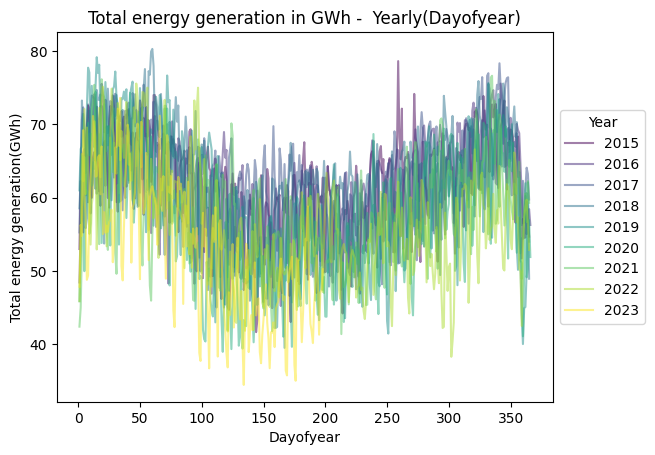

In [85]:
# Plot yearly seasonality
fig, ax = plt.subplots() 

pd.pivot_table(data=daily_data_df[['Year', 'Dayofyear', target]], index='Dayofyear', columns='Year') \
    [target] \
    .plot(cmap='viridis', alpha=0.5, ax=ax)

ax.legend(title='Year', loc='center left', bbox_to_anchor=(1, 0.5))
ax.set(title= title_main +' '+'-'+' ' + ' ' +'Yearly(Dayofyear)', ylabel=ylable_target);
#fig.savefig("visualisations/total_energy_generation_mwh.png",dpi=300)

In [86]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Total_other_renewable_gwh', 'Other_renewable_gwh', 'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh', 
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    average_lineplot(df=data_df, y=col, x='Date', time='Dayofyear', group='Year')

In [87]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr =  ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh','Other_renewable_gwh',  
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    average_lineplot(df=data_df, y=col, x='Date', time='Month', group='Year')

In [88]:
df_c = data_df.copy()

In [89]:
def combine_date_and_time(df, date_column='Date', time_column='Hour', target_column=target):
    # Convert 'Date' column to datetime format
    df['Date'] = pd.to_datetime(df['Date'])
    
    # Combine 'Date' and 'Hour' columns to create the 'Datetime' column
    df['Datetime'] = df.apply(lambda row: row[date_column] + pd.Timedelta(hours=row[time_column]), axis=1)
    
    # Select the desired columns for the final DataFrame
    df_result  = df[['Datetime', target_column]]
    
    return df_result

In [90]:
#print(dfs.shape)
#plt.figure()
#plt.plot(dfs['Date'], dfs[target])
#plt.autoscale(enable=True, axis='x', tight=True)
#plt.show();

In [91]:
df_dt = combine_date_and_time(df_c, date_column='Date', time_column='Hour', target_column=target)
df_dt.head()

,Datetime,Total_energy_generation_gwh
0,2015-01-01 00:00:00,51.45925
1,2015-01-01 01:00:00,49.98825
2,2015-01-01 02:00:00,49.26525
3,2015-01-01 03:00:00,48.53800
4,2015-01-01 04:00:00,48.63000


<Axes: xlabel='Datetime'>

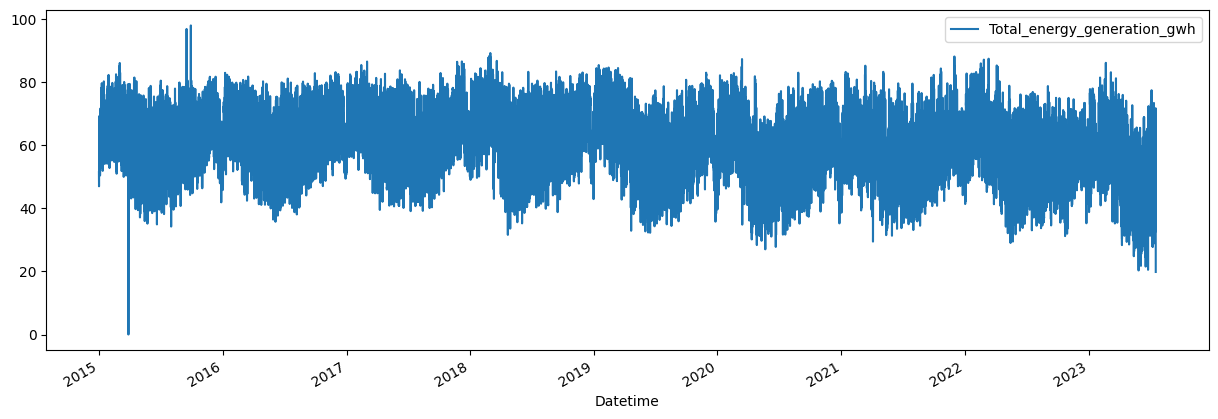

In [92]:
df_dt = df_dt.set_index('Datetime')
df_dt.plot(style = '-', figsize = (15,5), color='#1f76b4')

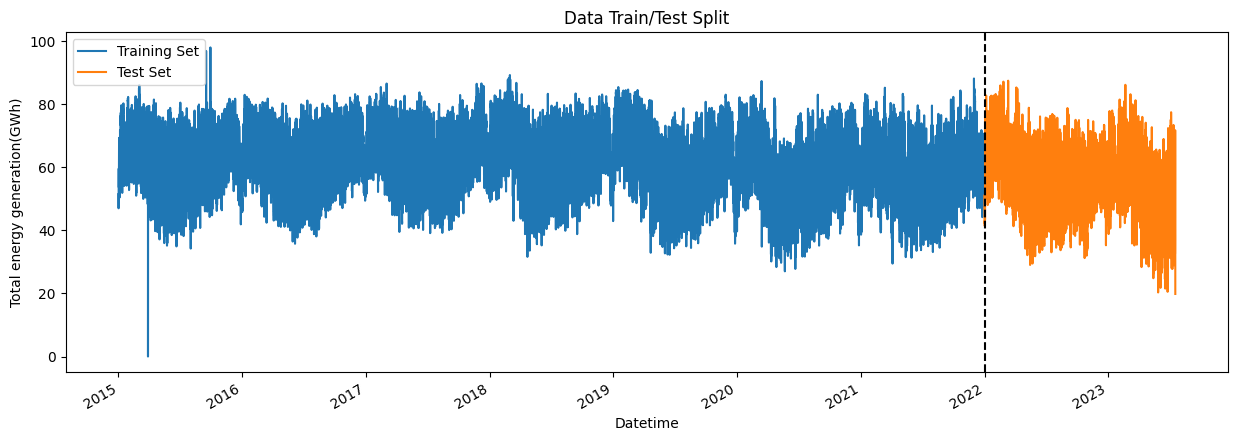

In [93]:
#df_c = pd.DataFrame(df_c.index)
#df_c.index
train =  df_dt.loc[df_dt.index < '2022-01-1']
test =  df_dt.loc[df_dt.index >= '2022-01-1']
fig, ax = plt.subplots(figsize=(15,5))
train.plot(ax=ax, label = 'Training Set', title= 'Data Train/Test Split')
test.plot (ax=ax, ylabel=ylable_target, label = 'Test Set')
ax.axvline('2022-01-1', color = 'black', ls= '--')
ax.legend(['Training Set','Test Set'])
#ax.ylabel(target)
plt.show()

In [94]:
def create_features(df):
    """
    create time series features based on time series index 
    """
    df['Hour'] = df.index.hour
    df['Year'] = df.index.year
    df['Month'] = df.index.month
    #df['Week'] = df.index.week
    #df['Week'] = df.index.weekofyear  # Use weekofyear instead of week
    df['Day'] = df.index.day
    #df['Dayofyear'] = df.index.dayofyear
    return df
df_dt = create_features(df_dt)
df_dt.head()

,Total_energy_generation_gwh,Hour,Year,Month,Day
Datetime,,,,,
2015-01-01 00:00:00,51.45925,0,2015,1,1
2015-01-01 01:00:00,49.98825,1,2015,1,1
2015-01-01 02:00:00,49.26525,2,2015,1,1
2015-01-01 03:00:00,48.53800,3,2015,1,1
2015-01-01 04:00:00,48.63000,4,2015,1,1


In [95]:
#features= ['Hour','Year', 'Month', 'Day']# 

In [96]:
#train = create_features(train)
#test = create_features(test)
#dfs = data_df[['Date',  target]]#train.head()

In [97]:
columns_to_keep= ['Date', 'Solar_gwh', 'Wind_onshore_gwh', 'Wind_offshore_gwh', 'Total_energy_generation_gwh'] #'Total_other_renewable_gwh'
#target = 'Total_energy_generation_gwh'
data_mlvt = data_df[columns_to_keep].copy()
data_mlvt.head()

,Date,Solar_gwh,Wind_onshore_gwh,Wind_offshore_gwh,Total_energy_generation_gwh
0,2015-01-01,0.0,8.84975,0.52100,51.45925
1,2015-01-01,0.0,9.04650,0.52075,49.98825
2,2015-01-01,0.0,9.19600,0.51900,49.26525
3,2015-01-01,0.0,9.14675,0.52250,48.53800
4,2015-01-01,0.0,9.20400,0.52425,48.63000


In [98]:
data_df.columns

Index(['Area', 'Mtu', 'Biomass_gwh', 'Fossil_brown_coal_gwh',
       'Fossil_coal_derived_gas_gwh', 'Fossil_gas_gwh', 'Fossil_hard_coal_gwh',
       'Fossil_oil_gwh', 'Fossil_oil_shale_gwh', 'Fossil_peat_gwh',
       'Geothermal_gwh', 'Hydro_pumped_storage_aggregated_gwh',
       'Hydro_pumped_storage_consumption_gwh',
       'Hydro_run_of_river_and_poundage_gwh', 'Hydro_water_reservoir_gwh',
       'Marine_gwh', 'Nuclear_gwh', 'Other_gwh', 'Other_renewable_gwh',
       'Solar_gwh', 'Waste_gwh', 'Wind_offshore_gwh', 'Wind_onshore_gwh',
       'Date', 'Hour', 'Total_energy_generation_gwh', 'Solar/total_energy',
       'Diff_total_energy_and_solar_gwh', 'Total_other_renewable_gwh', 'Year',
       'Month', 'Day', 'Dayofyear'],
      dtype='object')

#### Univariate LSTM time series 

#### SGD optimizer with momentum  

#### no dropout

/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_90496/2870798908.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs['Date'] = pd.to_datetime(dfs['Date'])


Epoch 1/400
1198/1198 [==============================] - 14s 11ms/step - loss: 0.0407 - val_loss: 0.0122
Epoch 2/400
1198/1198 [==============================] - 10s 8ms/step - loss: 0.0094 - val_loss: 0.0122
Epoch 3/400
1198/1198 [==============================] - 10s 8ms/step - loss: 0.0094 - val_loss: 0.0120
Epoch 4/400
1198/1198 [==============================] - 10s 9ms/step - loss: 0.0093 - val_loss: 0.0118
Epoch 5/400
1198/1198 [==============================] - 10s 8ms/step - loss: 0.0092 - val_loss: 0.0117
Epoch 6/400
1198/1198 [==============================] - 10s 8ms/step - loss: 0.0091 - val_loss: 0.0116
Epoch 7/400
1198/1198 [==============================] - 10s 8ms/step - loss: 0.0090 - val_loss: 0.0114
Epoch 8/400
1198/1198 [==============================] - 10s 8ms/step - loss: 0.0089 - val_loss: 0.0114
Epoch 9/400
1198/1198 [==============================] - 10s 8ms/step - loss: 0.0088 - val_loss: 0.0111
Epoch 10/400
1198/1198 [==============================] - 10s 9

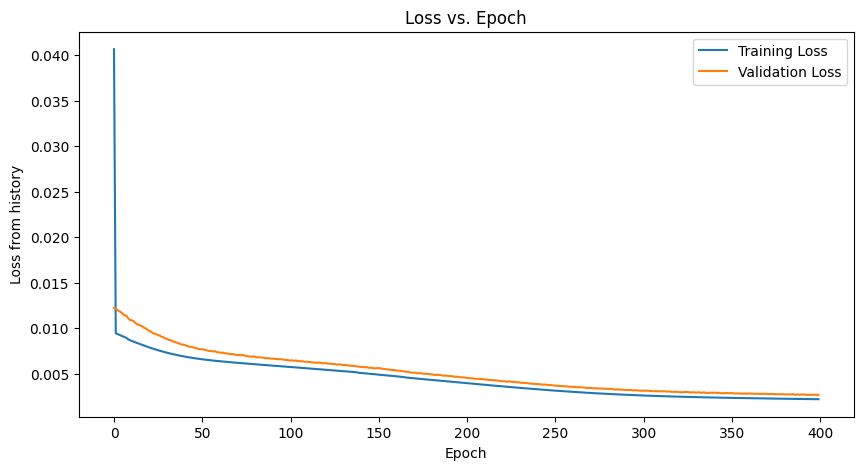

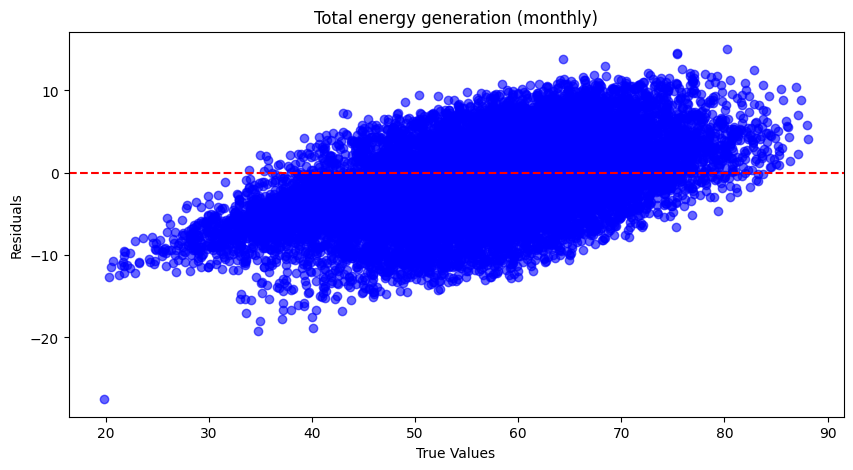

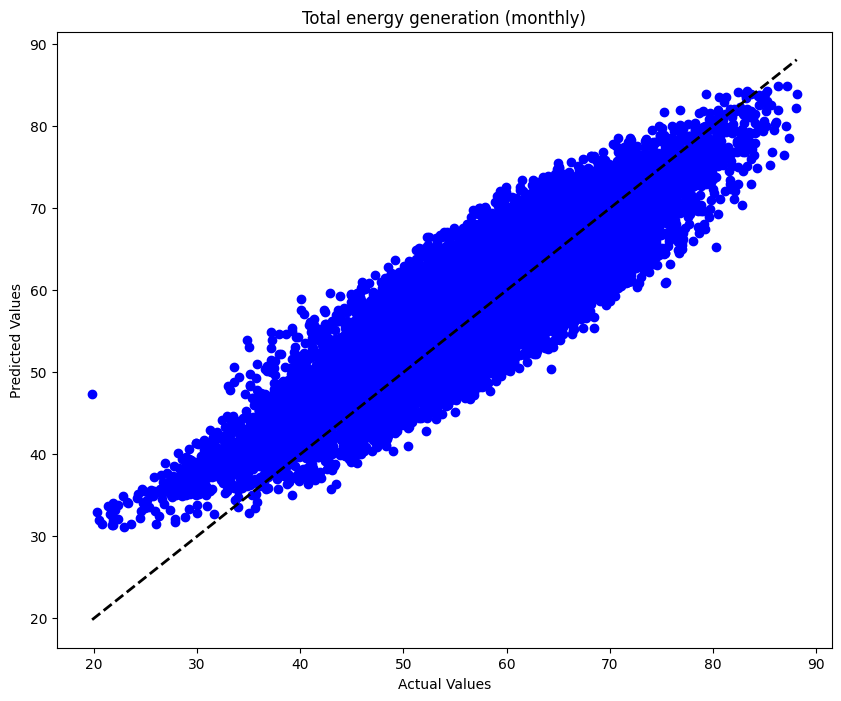

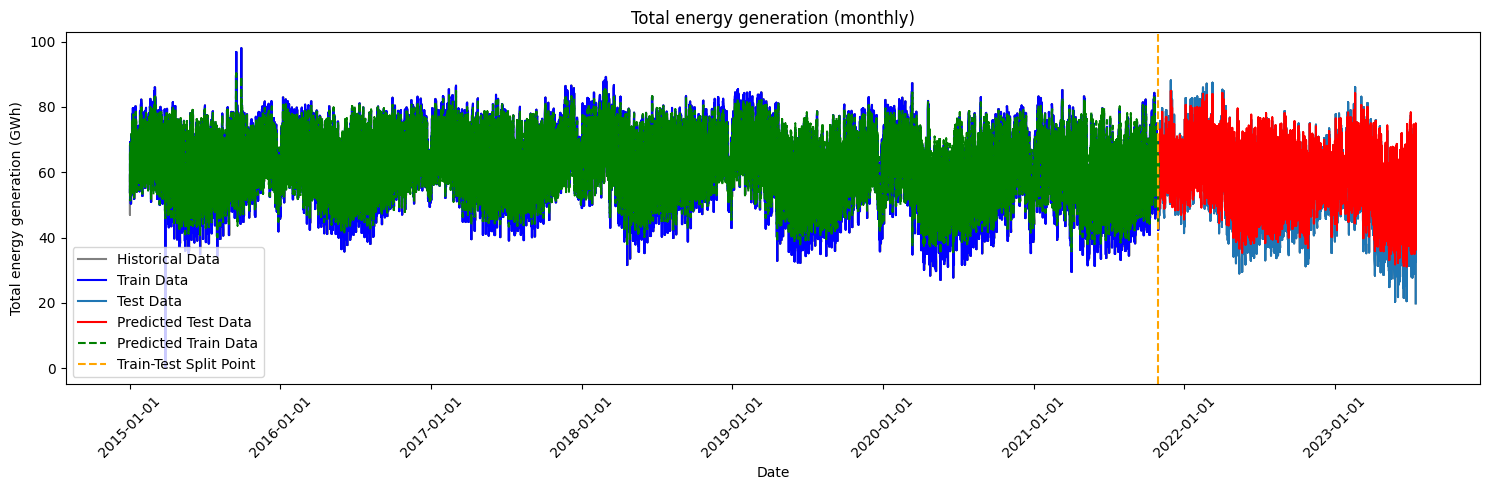

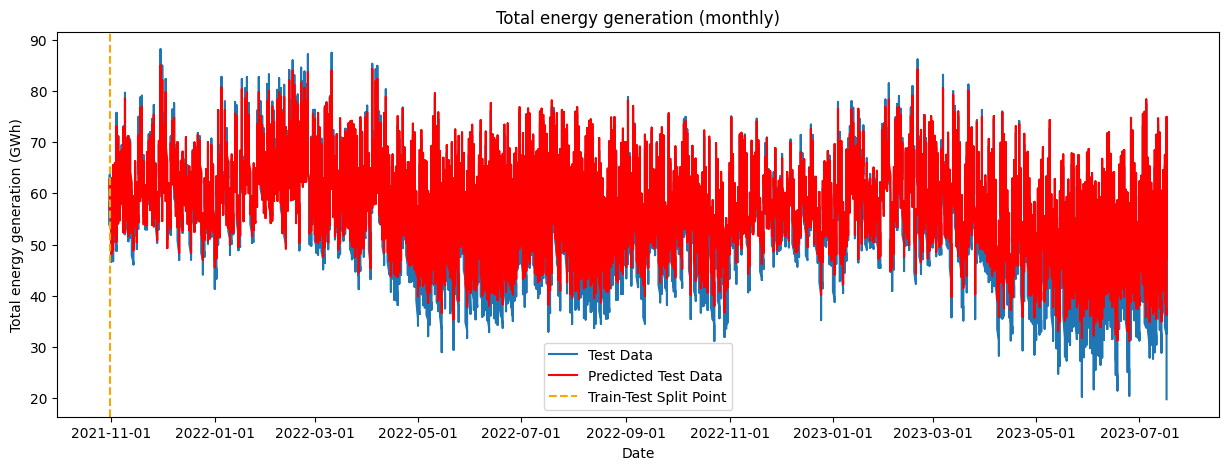

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_8 (LSTM)               (None, 12, 64)            16896     
                                                                 
 dropout_1 (Dropout)         (None, 12, 64)            0         
                                                                 
 lstm_9 (LSTM)               (None, 32)                12416     
                                                                 
 dense_4 (Dense)             (None, 1)                 33        
                                                                 
Total params: 29345 (114.63 KB)
Trainable params: 29345 (114.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None


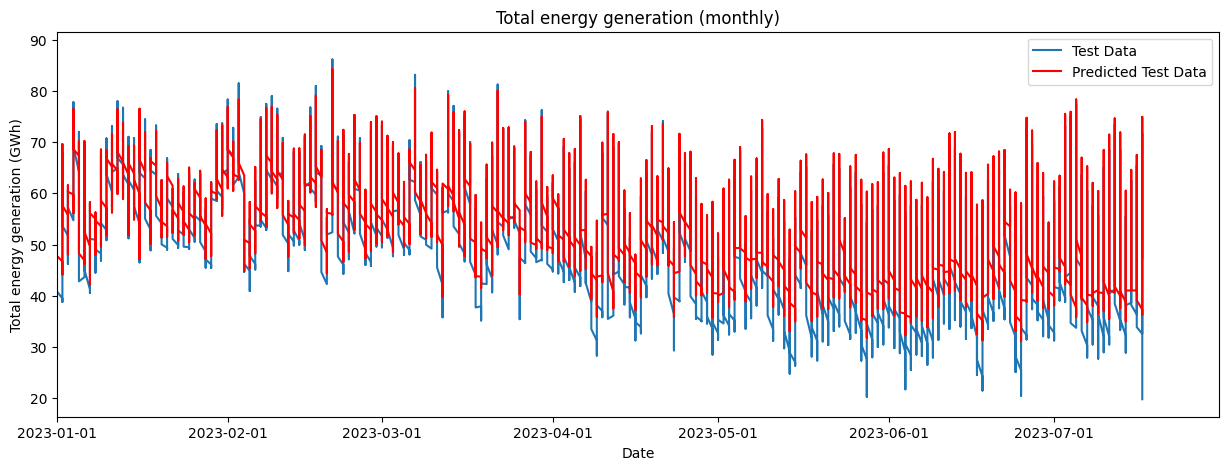

X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, df_shape = (59893, 12, 1) (14986, 12, 1) (59893, 1) (14986, 1) (74867, 12, 1) (74867, 1) (74879, 1)


In [101]:
def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback])
        y.append(data[i+lookback])
    return np.array(X), np.array(y)

def lstm_model(target, data_df, lookback):
    target_label = target.replace('_gwh', ' (GWh)').replace('_', ' ')
    main_target = target.replace('_', ' ').replace('gwh', '(monthly)')
    
    dfs = data_df[['Date', target]]
    dfs['Date'] = pd.to_datetime(dfs['Date'])
    dfs.set_index('Date', inplace=True)
    
    scaler = MinMaxScaler(feature_range=(0, 1))
    data_scaled = scaler.fit_transform(dfs[target].values.reshape(-1, 1))
   
    X_lstm, y_lstm = create_sequences(data_scaled, lookback)
    
    train_size = int(len(X_lstm) * 0.8)

    X_train_lstm, X_test_lstm = X_lstm[:train_size], X_lstm[train_size-lookback:]
    y_train_lstm, y_test_lstm = y_lstm[:train_size], y_lstm[train_size-lookback:]

    #optimizer = Adam(learning_rate=0.0001, beta_1=0.9, beta_2=0.99999)
    optimizer = SGD(learning_rate=0.0001, momentum=0.9)
    model = Sequential()
    model.add(LSTM(units=64, activation='relu', input_shape=(lookback, 1), return_sequences=True))
    model.add(Dropout(0.0))  # Adding dropout regularization to the first LSTM layer
    model.add(LSTM(units=32, activation='relu'))
    model.add(Dense(1))
    #TEST
    model.compile(loss='mse', optimizer= optimizer)
    ##
    ##
    # Adding early stopping to prevent overfitting
    early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

    history = model.fit(X_train_lstm, y_train_lstm, epochs=400, batch_size=50,
                        validation_data=(X_test_lstm, y_test_lstm),
                        callbacks=[early_stopping], verbose=1)

    print(model.summary())

    print ('After model fitting')
    print ('X_test_lstm = ',X_test_lstm.shape)
    print ('y_test_lstm = ',y_test_lstm.shape)
    print ('X_train_lstm = ',X_train_lstm.shape)
    print ('y_train_lstm = ',y_train_lstm.shape)


    y_pred_train_lstm = model.predict(X_train_lstm)
    y_pred_test_lstm = model.predict(X_test_lstm)
    
    print ('After prediction')

    print ('y_train_lstm = ',y_train_lstm.shape)
    print ('y_pred_train_lstm = ',y_pred_train_lstm.shape)
    print ('X_train_lstm = ',y_train_lstm.shape)

    print ('y_test_lstm = ',y_test_lstm.shape)
    print ('y_pred_test_lstm = ',y_pred_test_lstm.shape)
    print ('X_test_lstm = ',X_test_lstm.shape)
     

    y_pred_train_lstm = scaler.inverse_transform(y_pred_train_lstm)
    y_pred_test_lstm = scaler.inverse_transform(y_pred_test_lstm)
    y_train_lstm = scaler.inverse_transform(y_train_lstm)
    y_test_lstm = scaler.inverse_transform(y_test_lstm)
    
    print ('After inverse transformation on prediction data')
    print ('y_train_lstm = ',y_train_lstm.shape)
    print ('y_pred_train_lstm = ',y_pred_train_lstm.shape)
    print ('X_train_lstm = ',y_train_lstm.shape)

    print ('y_test_lstm = ',y_test_lstm.shape)
    print ('y_pred_test_lstm = ',y_pred_test_lstm.shape)
    print ('X_test_lstm = ',X_test_lstm.shape)
     
    train_rmse = np.sqrt(mean_squared_error(y_train_lstm, y_pred_train_lstm))
    test_rmse = np.sqrt(mean_squared_error(y_test_lstm, y_pred_test_lstm))
    train_mse = mean_squared_error(y_train_lstm, y_pred_train_lstm)
    test_mse = mean_squared_error(y_test_lstm, y_pred_test_lstm)
    train_mae = mean_absolute_error(y_train_lstm, y_pred_train_lstm)
    test_mae = mean_absolute_error(y_test_lstm, y_pred_test_lstm)
    train_r2 = r2_score(y_train_lstm, y_pred_train_lstm)
    test_r2 = r2_score(y_test_lstm, y_pred_test_lstm)

    print("Train RMSE:", train_rmse)
    print("Train MSE:", train_mse)
    print("Train MAE:", train_mae)
    print("Train R2 Score:", train_r2)
    print("Test RMSE:", test_rmse)
    print("Test MSE:", test_mse)
    print("Test MAE:", test_mae)
    print("Test R2 Score:", test_r2)

    residuals = y_test_lstm - y_pred_test_lstm

    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss from history')
    plt.title('Loss vs. Epoch')
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.scatter(y_test_lstm, residuals, color='blue', alpha=0.6)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.xlabel('True Values')
    plt.ylabel('Residuals')
    plt.title(main_target)
    plt.show()

    plt.figure(figsize=(10, 8))
    plt.scatter(y_test_lstm, y_pred_test_lstm, label='', color='blue')
    plt.plot([y_test_lstm.min(), y_test_lstm.max()], [y_test_lstm.min(), y_test_lstm.max()], 'k--', lw=2, label='')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(main_target)
    plt.show()

    plt.figure(figsize=(15, 5))
    train_index = dfs.index[:train_size][-len(y_train_lstm):]
    test_index = dfs.index[train_size:]
    plt.plot(dfs.index, dfs[target], label='Historical Data', color='gray')
    plt.plot(train_index, y_train_lstm, label='Train Data', color='blue')
    plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
    plt.plot(train_index, y_pred_train_lstm, label='Predicted Train Data', color='green', linestyle='dashed')
    plt.axvline(x=train_index[-1], color='orange', linestyle='--', label='Train-Test Split Point')
    plt.legend()
    # Format date ticks on x-axis
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
   
    plt.figure(figsize=(15, 5))
    train_index = dfs.index[:train_size][-len(y_train_lstm):]
    test_index = dfs.index[train_size:]
    plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
    plt.axvline(x=train_index[-1], color='orange', linestyle='--', label='Train-Test Split Point')
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.legend()
    #plt.xticks([])
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.show()

    print(model.summary()) 

    plt.figure(figsize=(15, 5))
    train_index = dfs.index[:train_size][-len(y_train_lstm):]
    test_index = dfs.index[train_size:]
    plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
    plt.xlim(pd.to_datetime('2023-01-01'), pd.to_datetime('2023-07-31'))  # Set xlim to the specified range
    plt.legend()
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    #plt.xticks([])
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.show()
    print('X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, df_shape =', X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, dfs.shape)
    return model
lookback=12
results = lstm_model('Total_energy_generation_gwh', data_df, lookback) 
#plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
#plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  
# Rest of the code, including lookback and calling lstm_model, remains unchanged.


In [ ]:
‚‚‚

#### dropout 0.2

/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_90496/114314477.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs['Date'] = pd.to_datetime(dfs['Date'])


Epoch 1/400
1198/1198 [==============================] - 18s 14ms/step - loss: 0.0629 - val_loss: 0.0140
Epoch 2/400
1198/1198 [==============================] - 13s 11ms/step - loss: 0.0110 - val_loss: 0.0143
Epoch 3/400
1198/1198 [==============================] - 12s 10ms/step - loss: 0.0109 - val_loss: 0.0142
Epoch 4/400
1198/1198 [==============================] - 14s 12ms/step - loss: 0.0108 - val_loss: 0.0140
Epoch 5/400
1198/1198 [==============================] - 14s 12ms/step - loss: 0.0107 - val_loss: 0.0138
Epoch 6/400
1198/1198 [==============================] - 13s 11ms/step - loss: 0.0106 - val_loss: 0.0138
Epoch 7/400
1198/1198 [==============================] - 14s 12ms/step - loss: 0.0106 - val_loss: 0.0139
Epoch 8/400
1198/1198 [==============================] - 13s 11ms/step - loss: 0.0105 - val_loss: 0.0137
Epoch 9/400
1198/1198 [==============================] - 14s 11ms/step - loss: 0.0105 - val_loss: 0.0136
Epoch 10/400
1198/1198 [==============================]

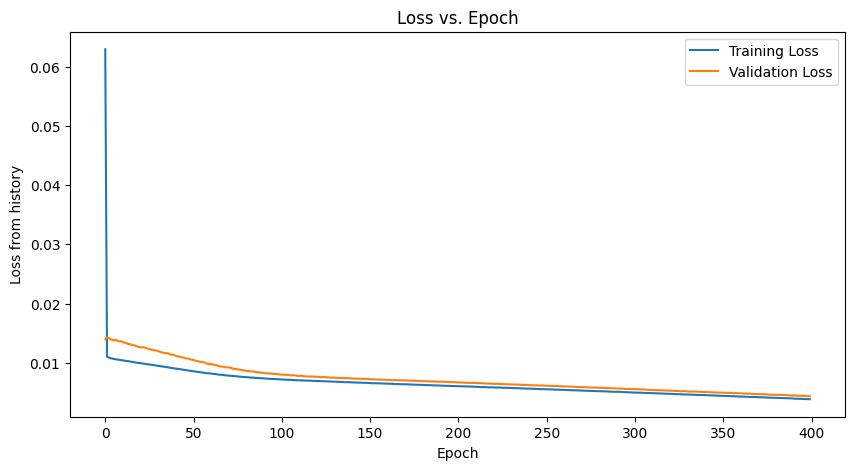

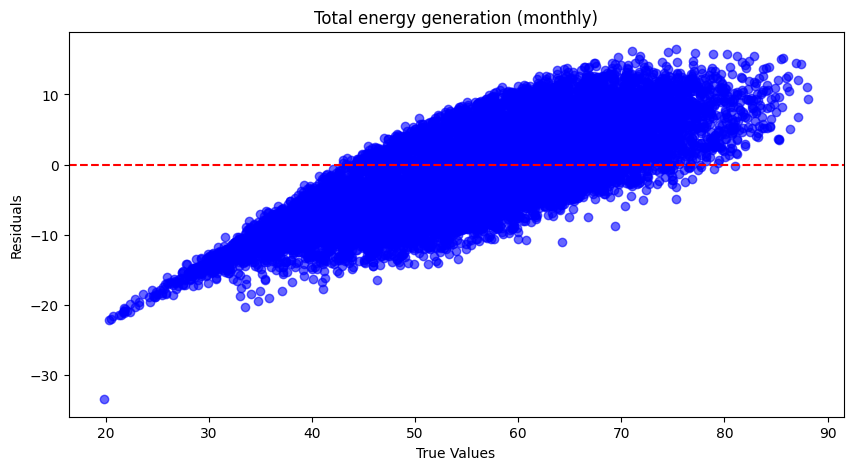

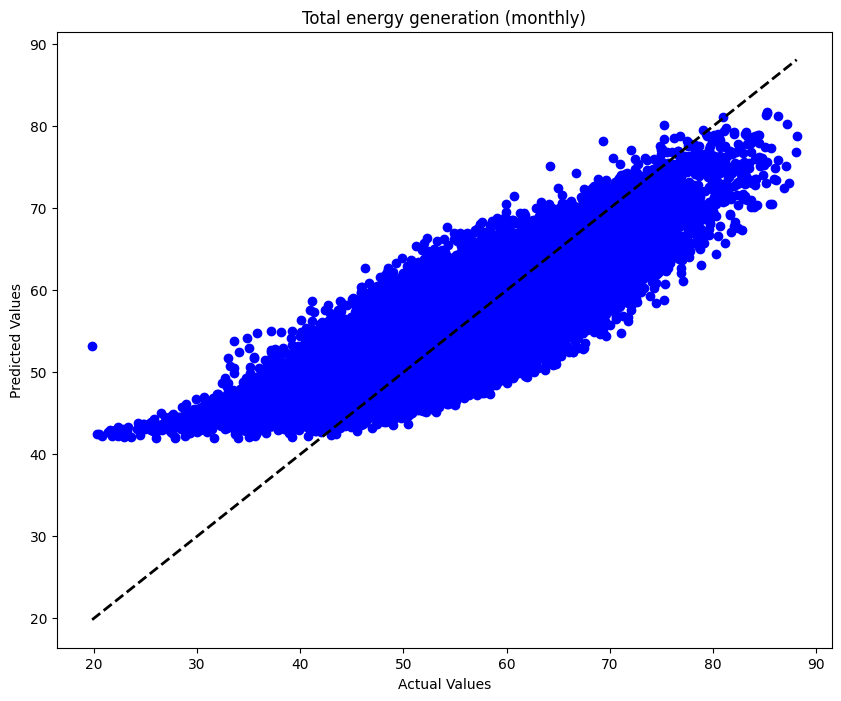

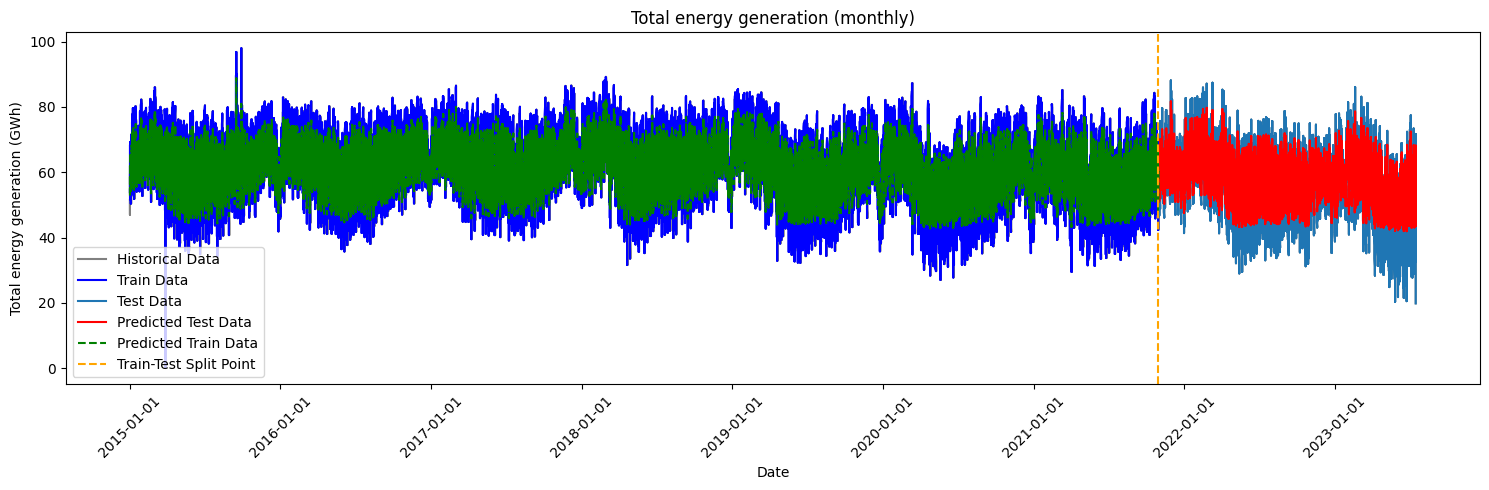

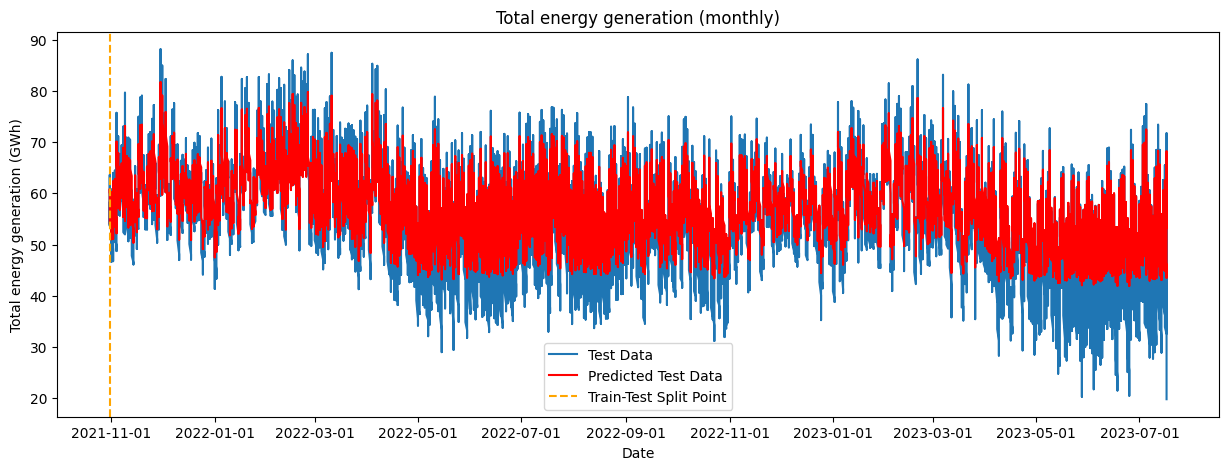

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_10 (LSTM)              (None, 12, 64)            16896     
                                                                 
 dropout_2 (Dropout)         (None, 12, 64)            0         
                                                                 
 lstm_11 (LSTM)              (None, 32)                12416     
                                                                 
 dense_5 (Dense)             (None, 1)                 33        
                                                                 
Total params: 29345 (114.63 KB)
Trainable params: 29345 (114.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None


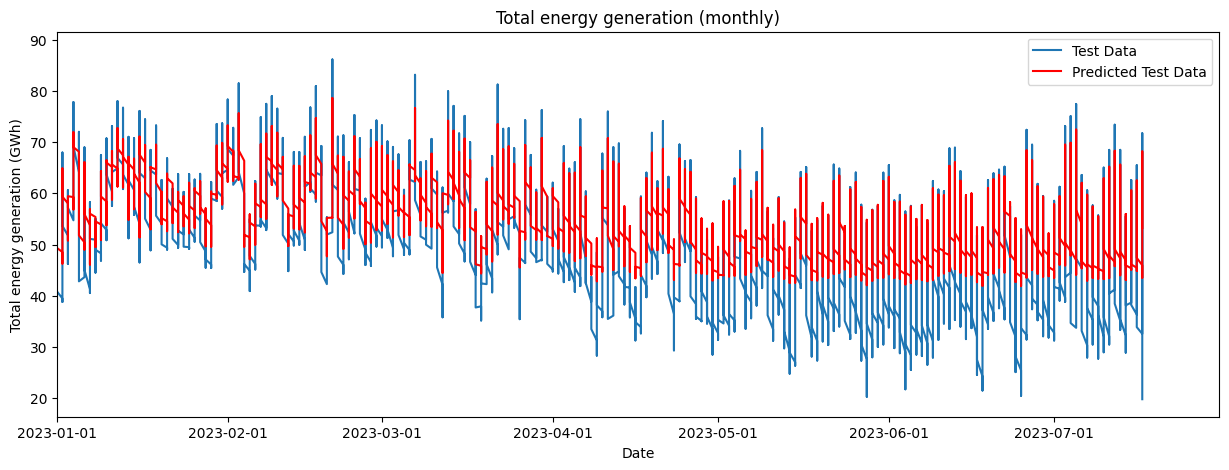

X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, df_shape = (59893, 12, 1) (14986, 12, 1) (59893, 1) (14986, 1) (74867, 12, 1) (74867, 1) (74879, 1)


In [102]:
def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback])
        y.append(data[i+lookback])
    return np.array(X), np.array(y)

def lstm_model(target, data_df, lookback):
    target_label = target.replace('_gwh', ' (GWh)').replace('_', ' ')
    main_target = target.replace('_', ' ').replace('gwh', '(monthly)')
    
    dfs = data_df[['Date', target]]
    dfs['Date'] = pd.to_datetime(dfs['Date'])
    dfs.set_index('Date', inplace=True)
    
    scaler = MinMaxScaler(feature_range=(0, 1))
    data_scaled = scaler.fit_transform(dfs[target].values.reshape(-1, 1))
   
    X_lstm, y_lstm = create_sequences(data_scaled, lookback)
    
    train_size = int(len(X_lstm) * 0.8)

    X_train_lstm, X_test_lstm = X_lstm[:train_size], X_lstm[train_size-lookback:]
    y_train_lstm, y_test_lstm = y_lstm[:train_size], y_lstm[train_size-lookback:]

    #optimizer = Adam(learning_rate=0.0001, beta_1=0.9, beta_2=0.99999)
    optimizer = SGD(learning_rate=0.0001, momentum=0.9)
    model = Sequential()
    model.add(LSTM(units=64, activation='relu', input_shape=(lookback, 1), return_sequences=True))
    model.add(Dropout(0.2))  # Adding dropout regularization to the first LSTM layer
    model.add(LSTM(units=32, activation='relu'))
    model.add(Dense(1))
    #TEST
    model.compile(loss='mse', optimizer= optimizer)
    ##
    ##
    # Adding early stopping to prevent overfitting
    early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

    history = model.fit(X_train_lstm, y_train_lstm, epochs=400, batch_size=50,
                        validation_data=(X_test_lstm, y_test_lstm),
                        callbacks=[early_stopping], verbose=1)

    print(model.summary())

    print ('After model fitting')
    print ('X_test_lstm = ',X_test_lstm.shape)
    print ('y_test_lstm = ',y_test_lstm.shape)
    print ('X_train_lstm = ',X_train_lstm.shape)
    print ('y_train_lstm = ',y_train_lstm.shape)


    y_pred_train_lstm = model.predict(X_train_lstm)
    y_pred_test_lstm = model.predict(X_test_lstm)
    
    print ('After prediction')

    print ('y_train_lstm = ',y_train_lstm.shape)
    print ('y_pred_train_lstm = ',y_pred_train_lstm.shape)
    print ('X_train_lstm = ',y_train_lstm.shape)

    print ('y_test_lstm = ',y_test_lstm.shape)
    print ('y_pred_test_lstm = ',y_pred_test_lstm.shape)
    print ('X_test_lstm = ',X_test_lstm.shape)
     

    y_pred_train_lstm = scaler.inverse_transform(y_pred_train_lstm)
    y_pred_test_lstm = scaler.inverse_transform(y_pred_test_lstm)
    y_train_lstm = scaler.inverse_transform(y_train_lstm)
    y_test_lstm = scaler.inverse_transform(y_test_lstm)
    
    print ('After inverse transformation on prediction data')
    print ('y_train_lstm = ',y_train_lstm.shape)
    print ('y_pred_train_lstm = ',y_pred_train_lstm.shape)
    print ('X_train_lstm = ',y_train_lstm.shape)

    print ('y_test_lstm = ',y_test_lstm.shape)
    print ('y_pred_test_lstm = ',y_pred_test_lstm.shape)
    print ('X_test_lstm = ',X_test_lstm.shape)
     
    train_rmse = np.sqrt(mean_squared_error(y_train_lstm, y_pred_train_lstm))
    test_rmse = np.sqrt(mean_squared_error(y_test_lstm, y_pred_test_lstm))
    train_mse = mean_squared_error(y_train_lstm, y_pred_train_lstm)
    test_mse = mean_squared_error(y_test_lstm, y_pred_test_lstm)
    train_mae = mean_absolute_error(y_train_lstm, y_pred_train_lstm)
    test_mae = mean_absolute_error(y_test_lstm, y_pred_test_lstm)
    train_r2 = r2_score(y_train_lstm, y_pred_train_lstm)
    test_r2 = r2_score(y_test_lstm, y_pred_test_lstm)

    print("Train RMSE:", train_rmse)
    print("Train MSE:", train_mse)
    print("Train MAE:", train_mae)
    print("Train R2 Score:", train_r2)
    print("Test RMSE:", test_rmse)
    print("Test MSE:", test_mse)
    print("Test MAE:", test_mae)
    print("Test R2 Score:", test_r2)

    residuals = y_test_lstm - y_pred_test_lstm

    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss from history')
    plt.title('Loss vs. Epoch')
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.scatter(y_test_lstm, residuals, color='blue', alpha=0.6)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.xlabel('True Values')
    plt.ylabel('Residuals')
    plt.title(main_target)
    plt.show()

    plt.figure(figsize=(10, 8))
    plt.scatter(y_test_lstm, y_pred_test_lstm, label='', color='blue')
    plt.plot([y_test_lstm.min(), y_test_lstm.max()], [y_test_lstm.min(), y_test_lstm.max()], 'k--', lw=2, label='')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(main_target)
    plt.show()

    plt.figure(figsize=(15, 5))
    train_index = dfs.index[:train_size][-len(y_train_lstm):]
    test_index = dfs.index[train_size:]
    plt.plot(dfs.index, dfs[target], label='Historical Data', color='gray')
    plt.plot(train_index, y_train_lstm, label='Train Data', color='blue')
    plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
    plt.plot(train_index, y_pred_train_lstm, label='Predicted Train Data', color='green', linestyle='dashed')
    plt.axvline(x=train_index[-1], color='orange', linestyle='--', label='Train-Test Split Point')
    plt.legend()
    # Format date ticks on x-axis
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
   
    plt.figure(figsize=(15, 5))
    train_index = dfs.index[:train_size][-len(y_train_lstm):]
    test_index = dfs.index[train_size:]
    plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
    plt.axvline(x=train_index[-1], color='orange', linestyle='--', label='Train-Test Split Point')
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.legend()
    #plt.xticks([])
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.show()

    print(model.summary()) 

    plt.figure(figsize=(15, 5))
    train_index = dfs.index[:train_size][-len(y_train_lstm):]
    test_index = dfs.index[train_size:]
    plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
    plt.xlim(pd.to_datetime('2023-01-01'), pd.to_datetime('2023-07-31'))  # Set xlim to the specified range
    plt.legend()
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    #plt.xticks([])
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.show()
    print('X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, df_shape =', X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, dfs.shape)
    return model
lookback=12
results = lstm_model('Total_energy_generation_gwh', data_df, lookback) 
#plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
#plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  
# Rest of the code, including lookback and calling lstm_model, remains unchanged.


/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_90496/174724271.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs['Date'] = pd.to_datetime(dfs['Date'])


Epoch 1/400
1198/1198 [==============================] - 14s 11ms/step - loss: 0.0315 - val_loss: 0.0551
Epoch 2/400
1198/1198 [==============================] - 11s 9ms/step - loss: 0.0298 - val_loss: 0.0544
Epoch 3/400
1198/1198 [==============================] - 11s 9ms/step - loss: 0.0295 - val_loss: 0.0541
Epoch 4/400
1198/1198 [==============================] - 11s 9ms/step - loss: 0.0294 - val_loss: 0.0537
Epoch 5/400
1198/1198 [==============================] - 10s 9ms/step - loss: 0.0292 - val_loss: 0.0533
Epoch 6/400
1198/1198 [==============================] - 10s 9ms/step - loss: 0.0290 - val_loss: 0.0531
Epoch 7/400
1198/1198 [==============================] - 10s 9ms/step - loss: 0.0289 - val_loss: 0.0527
Epoch 8/400
1198/1198 [==============================] - 10s 9ms/step - loss: 0.0288 - val_loss: 0.0525
Epoch 9/400
1198/1198 [==============================] - 10s 9ms/step - loss: 0.0286 - val_loss: 0.0524
Epoch 10/400
1198/1198 [==============================] - 10s 8

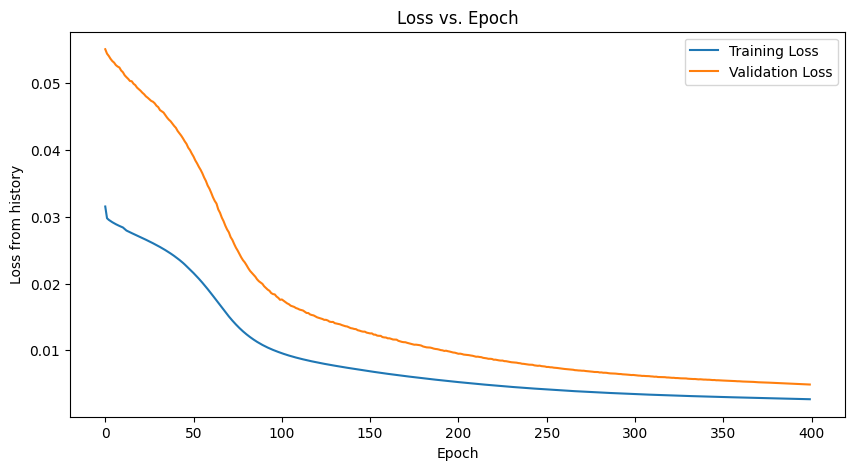

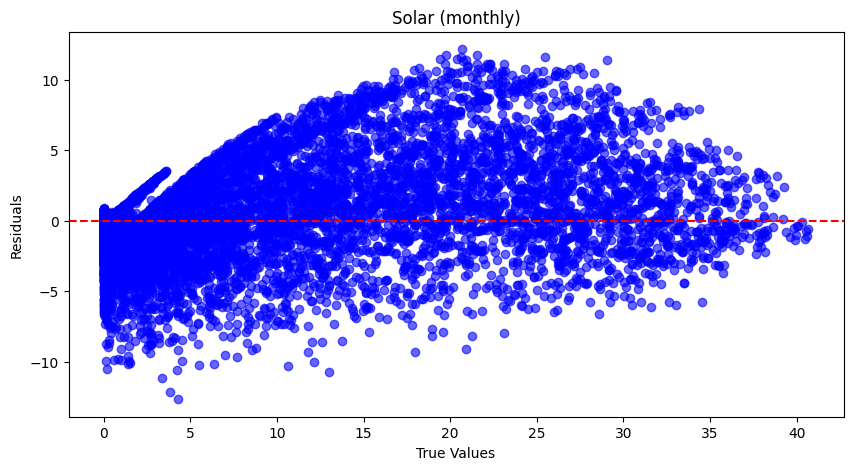

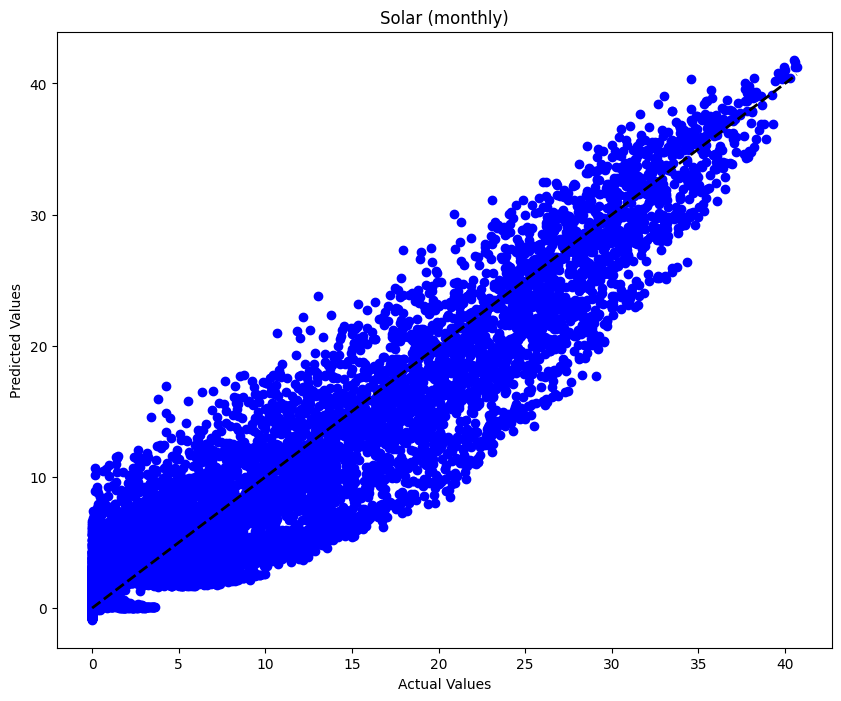

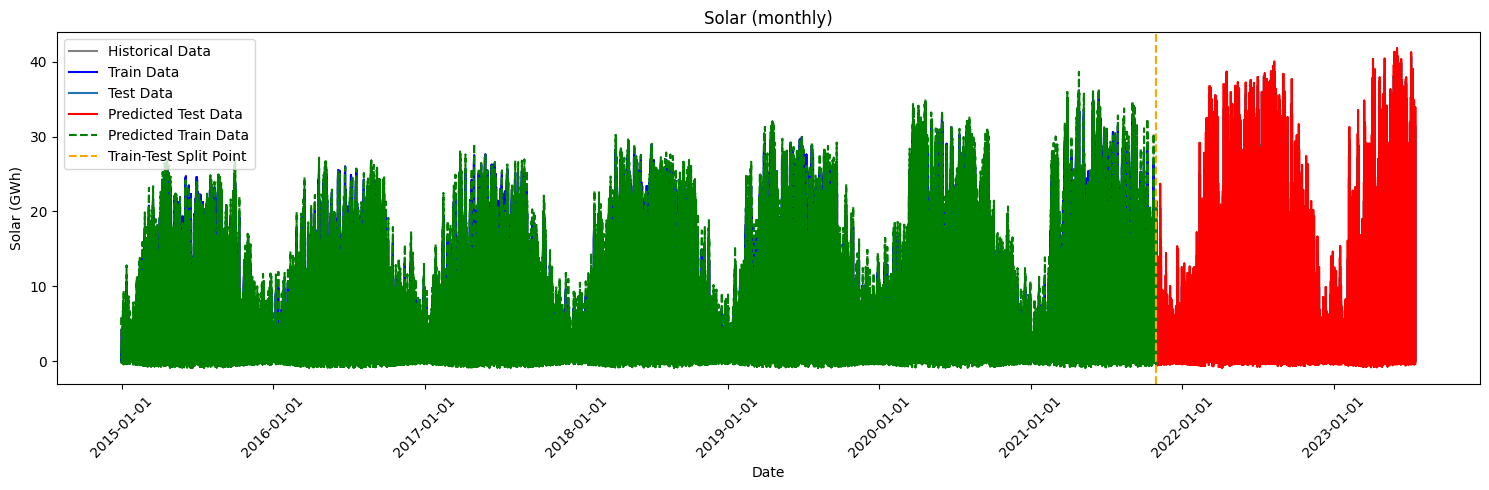

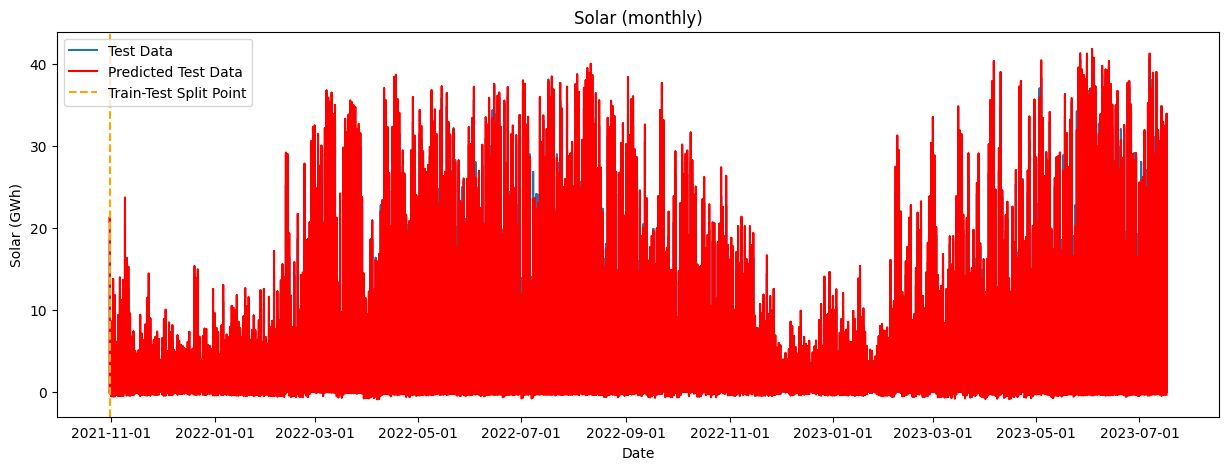

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_6 (LSTM)               (None, 12, 64)            16896     
                                                                 
 dropout (Dropout)           (None, 12, 64)            0         
                                                                 
 lstm_7 (LSTM)               (None, 32)                12416     
                                                                 
 dense_3 (Dense)             (None, 1)                 33        
                                                                 
Total params: 29345 (114.63 KB)
Trainable params: 29345 (114.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None


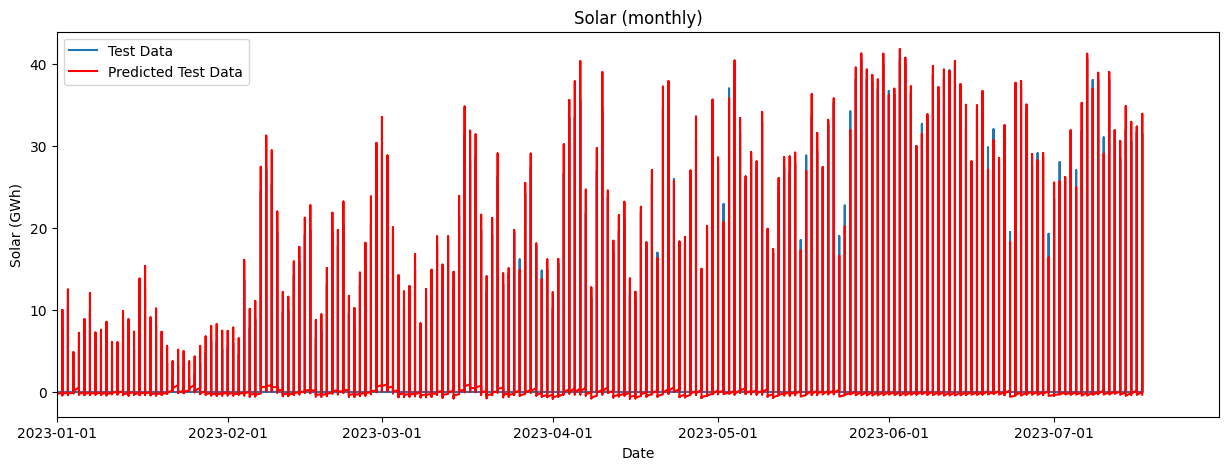

X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, df_shape = (59893, 12, 1) (14986, 12, 1) (59893, 1) (14986, 1) (74867, 12, 1) (74867, 1) (74879, 1)


In [100]:
def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback])
        y.append(data[i+lookback])
    return np.array(X), np.array(y)

def lstm_model(target, data_df, lookback):
    target_label = target.replace('_gwh', ' (GWh)').replace('_', ' ')
    main_target = target.replace('_', ' ').replace('gwh', '(monthly)')
    
    dfs = data_df[['Date', target]]
    dfs['Date'] = pd.to_datetime(dfs['Date'])
    dfs.set_index('Date', inplace=True)
    
    scaler = MinMaxScaler(feature_range=(0, 1))
    data_scaled = scaler.fit_transform(dfs[target].values.reshape(-1, 1))
   
    X_lstm, y_lstm = create_sequences(data_scaled, lookback)
    
    train_size = int(len(X_lstm) * 0.8)

    X_train_lstm, X_test_lstm = X_lstm[:train_size], X_lstm[train_size-lookback:]
    y_train_lstm, y_test_lstm = y_lstm[:train_size], y_lstm[train_size-lookback:]

    #optimizer = Adam(learning_rate=0.0001, beta_1=0.9, beta_2=0.99999)
    optimizer = SGD(learning_rate=0.0001, momentum=0.9)
    model = Sequential()
    model.add(LSTM(units=64, activation='relu', input_shape=(lookback, 1), return_sequences=True))
    model.add(Dropout(0.0))  # Adding dropout regularization to the first LSTM layer
    model.add(LSTM(units=32, activation='relu'))
    model.add(Dense(1))
    #TEST
    model.compile(loss='mse', optimizer= optimizer)
    ##
    ##
    # Adding early stopping to prevent overfitting
    early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

    history = model.fit(X_train_lstm, y_train_lstm, epochs=400, batch_size=50,
                        validation_data=(X_test_lstm, y_test_lstm),
                        callbacks=[early_stopping], verbose=1)

    print(model.summary())

    print ('After model fitting')
    print ('X_test_lstm = ',X_test_lstm.shape)
    print ('y_test_lstm = ',y_test_lstm.shape)
    print ('X_train_lstm = ',X_train_lstm.shape)
    print ('y_train_lstm = ',y_train_lstm.shape)


    y_pred_train_lstm = model.predict(X_train_lstm)
    y_pred_test_lstm = model.predict(X_test_lstm)
    
    print ('After prediction')

    print ('y_train_lstm = ',y_train_lstm.shape)
    print ('y_pred_train_lstm = ',y_pred_train_lstm.shape)
    print ('X_train_lstm = ',y_train_lstm.shape)

    print ('y_test_lstm = ',y_test_lstm.shape)
    print ('y_pred_test_lstm = ',y_pred_test_lstm.shape)
    print ('X_test_lstm = ',X_test_lstm.shape)
     

    y_pred_train_lstm = scaler.inverse_transform(y_pred_train_lstm)
    y_pred_test_lstm = scaler.inverse_transform(y_pred_test_lstm)
    y_train_lstm = scaler.inverse_transform(y_train_lstm)
    y_test_lstm = scaler.inverse_transform(y_test_lstm)
    
    print ('After inverse transformation on prediction data')
    print ('y_train_lstm = ',y_train_lstm.shape)
    print ('y_pred_train_lstm = ',y_pred_train_lstm.shape)
    print ('X_train_lstm = ',y_train_lstm.shape)

    print ('y_test_lstm = ',y_test_lstm.shape)
    print ('y_pred_test_lstm = ',y_pred_test_lstm.shape)
    print ('X_test_lstm = ',X_test_lstm.shape)
     
    train_rmse = np.sqrt(mean_squared_error(y_train_lstm, y_pred_train_lstm))
    test_rmse = np.sqrt(mean_squared_error(y_test_lstm, y_pred_test_lstm))
    train_mse = mean_squared_error(y_train_lstm, y_pred_train_lstm)
    test_mse = mean_squared_error(y_test_lstm, y_pred_test_lstm)
    train_mae = mean_absolute_error(y_train_lstm, y_pred_train_lstm)
    test_mae = mean_absolute_error(y_test_lstm, y_pred_test_lstm)
    train_r2 = r2_score(y_train_lstm, y_pred_train_lstm)
    test_r2 = r2_score(y_test_lstm, y_pred_test_lstm)

    print("Train RMSE:", train_rmse)
    print("Train MSE:", train_mse)
    print("Train MAE:", train_mae)
    print("Train R2 Score:", train_r2)
    print("Test RMSE:", test_rmse)
    print("Test MSE:", test_mse)
    print("Test MAE:", test_mae)
    print("Test R2 Score:", test_r2)

    residuals = y_test_lstm - y_pred_test_lstm

    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss from history')
    plt.title('Loss vs. Epoch')
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.scatter(y_test_lstm, residuals, color='blue', alpha=0.6)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.xlabel('True Values')
    plt.ylabel('Residuals')
    plt.title(main_target)
    plt.show()

    plt.figure(figsize=(10, 8))
    plt.scatter(y_test_lstm, y_pred_test_lstm, label='', color='blue')
    plt.plot([y_test_lstm.min(), y_test_lstm.max()], [y_test_lstm.min(), y_test_lstm.max()], 'k--', lw=2, label='')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(main_target)
    plt.show()

    plt.figure(figsize=(15, 5))
    train_index = dfs.index[:train_size][-len(y_train_lstm):]
    test_index = dfs.index[train_size:]
    plt.plot(dfs.index, dfs[target], label='Historical Data', color='gray')
    plt.plot(train_index, y_train_lstm, label='Train Data', color='blue')
    plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
    plt.plot(train_index, y_pred_train_lstm, label='Predicted Train Data', color='green', linestyle='dashed')
    plt.axvline(x=train_index[-1], color='orange', linestyle='--', label='Train-Test Split Point')
    plt.legend()
    # Format date ticks on x-axis
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
   
    plt.figure(figsize=(15, 5))
    train_index = dfs.index[:train_size][-len(y_train_lstm):]
    test_index = dfs.index[train_size:]
    plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
    plt.axvline(x=train_index[-1], color='orange', linestyle='--', label='Train-Test Split Point')
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.legend()
    #plt.xticks([])
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.show()

    print(model.summary()) 

    plt.figure(figsize=(15, 5))
    train_index = dfs.index[:train_size][-len(y_train_lstm):]
    test_index = dfs.index[train_size:]
    plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
    plt.xlim(pd.to_datetime('2023-01-01'), pd.to_datetime('2023-07-31'))  # Set xlim to the specified range
    plt.legend()
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    #plt.xticks([])
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.show()
    print('X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, df_shape =', X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, dfs.shape)
    return model
lookback=12
results = lstm_model('Solar_gwh', data_df, lookback) 
#plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
#plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  
# Rest of the code, including lookback and calling lstm_model, remains unchanged.


#### with dropout

#### With ADM optimzer

/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_90496/3549749090.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs['Date'] = pd.to_datetime(dfs['Date'])


data_df_shape, data_scaled_shape, X_lstm_shape, y_lstm_shape, X_lstm_shape[0]+X_lstm_shape[1]= (74879, 33) (74879, 1) (74867, 12, 1) (74867, 1) 74879
X_train_lstm_shape, X_test_lstm_shape, y_train_lstm_shape, y_test_lstm_shape = (59893, 12, 1) (14986, 12, 1) (59893, 1) (14986, 1)
Before model fitting
X_test_lstm =  (14986, 12, 1)
y_test_lstm =  (14986, 1)
X_train_lstm =  (59893, 12, 1)
y_train_lstm =  (59893, 1)
Epoch 1/50
2995/2995 [==============================] - 15s 5ms/step - loss: 0.0019 - val_loss: 4.7048e-04
Epoch 2/50
2995/2995 [==============================] - 14s 5ms/step - loss: 1.7214e-04 - val_loss: 2.1033e-04
Epoch 3/50
2995/2995 [==============================] - 14s 5ms/step - loss: 1.3069e-04 - val_loss: 1.6900e-04
Epoch 4/50
2995/2995 [==============================] - 14s 5ms/step - loss: 1.0867e-04 - val_loss: 1.4882e-04
Epoch 5/50
2995/2995 [==============================] - 14s 5ms/step - loss: 8.8737e-05 - val_loss: 1.2947e-04
Epoch 6/50
2995/2995 [===========

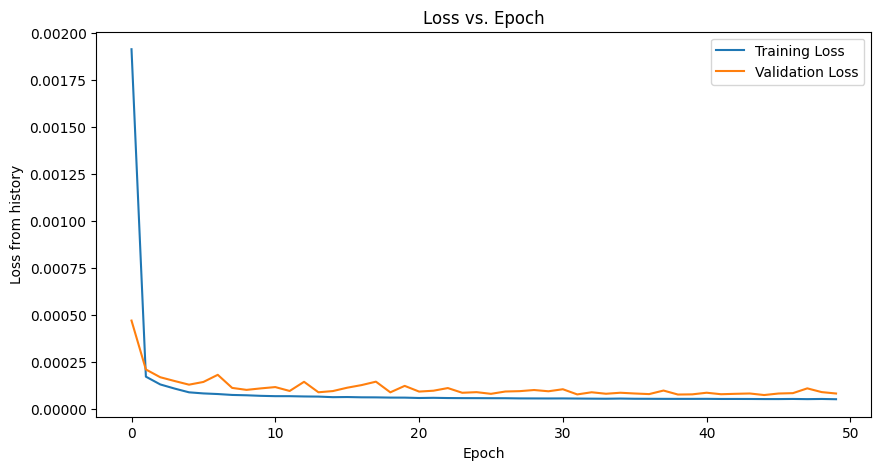

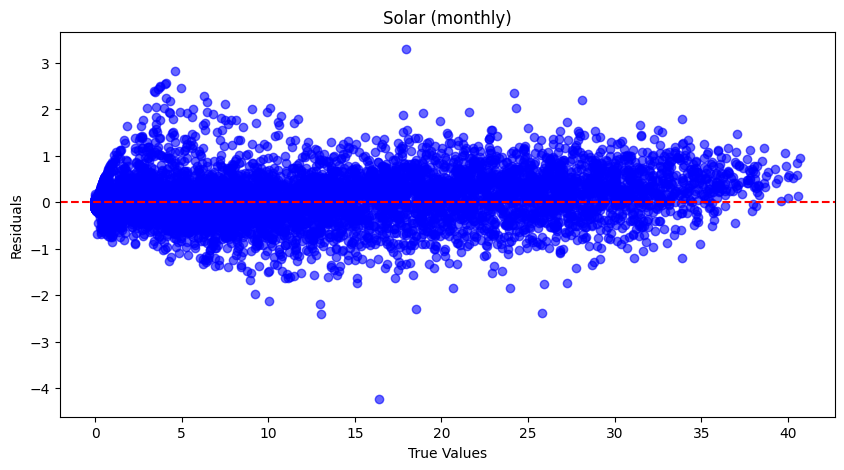

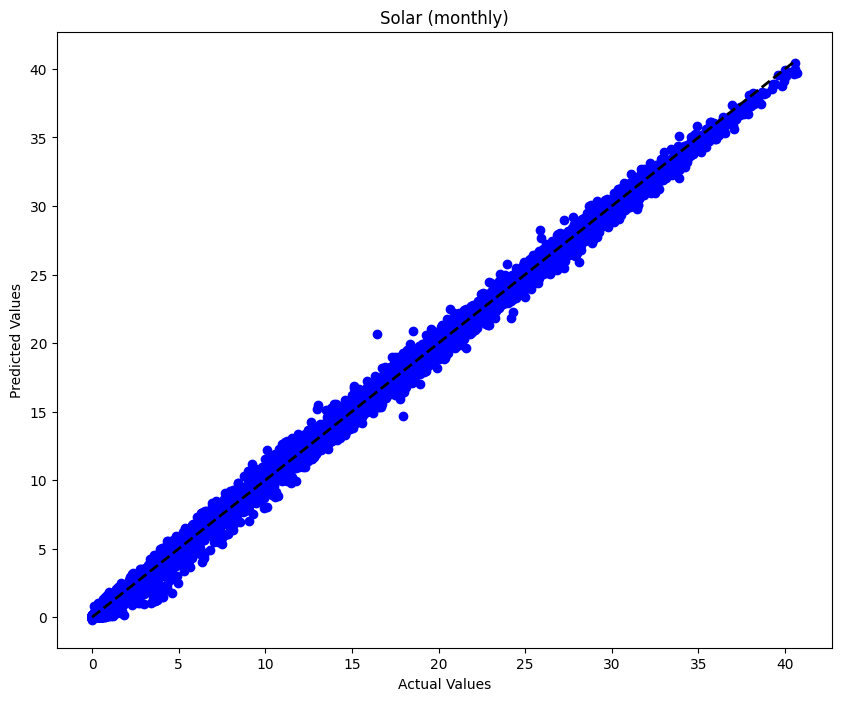

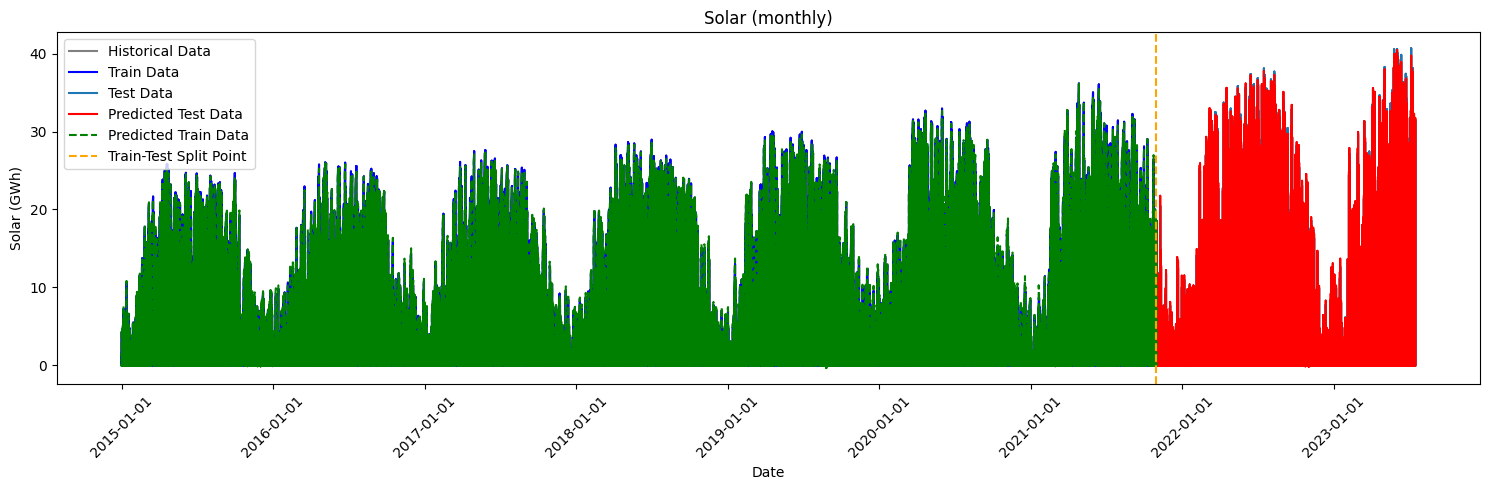

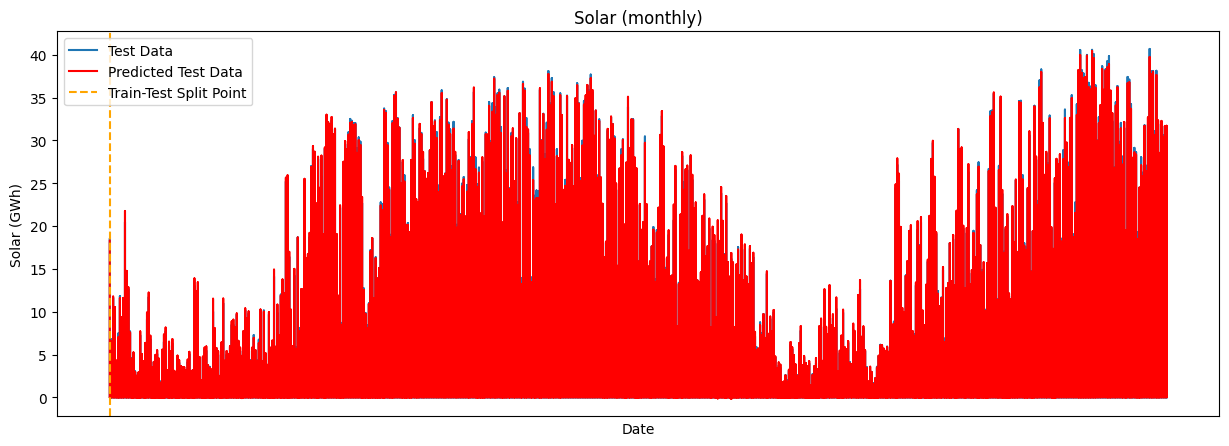

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_4 (LSTM)               (None, 12, 64)            16896     
                                                                 
 lstm_5 (LSTM)               (None, 32)                12416     
                                                                 
 dense_2 (Dense)             (None, 1)                 33        
                                                                 
Total params: 29345 (114.63 KB)
Trainable params: 29345 (114.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None


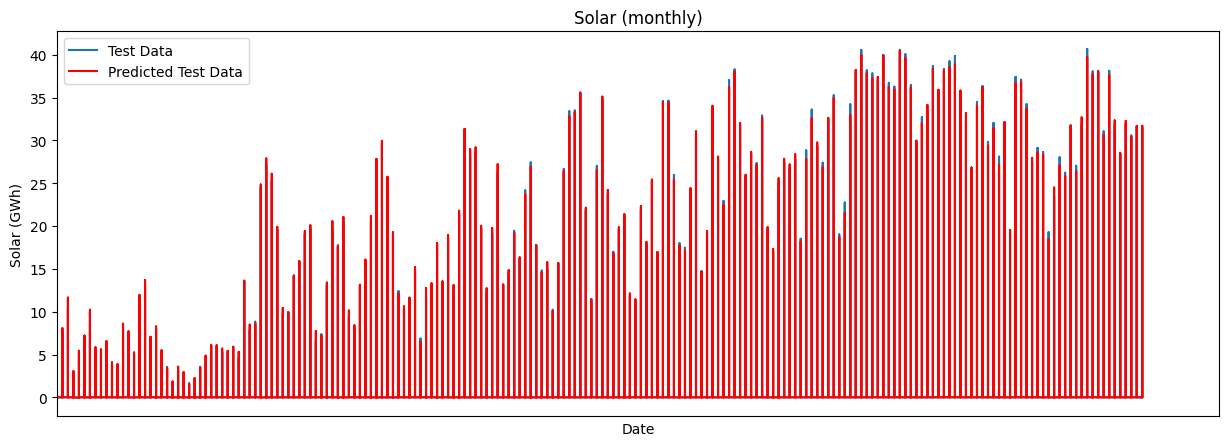

X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, df_shape = (59893, 12, 1) (14986, 12, 1) (59893, 1) (14986, 1) (74867, 12, 1) (74867, 1) (74879, 1)


In [51]:
def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback])
        y.append(data[i+lookback])
    return np.array(X), np.array(y)

def lstm_model(target, data_df, lookback):
   
    target_label = target.replace('_gwh', ' (GWh)').replace('_', ' ')
    main_target = target.replace('_', ' ').replace('gwh', '(monthly)')
    
    dfs = data_df[['Date', target]]
    dfs['Date'] = pd.to_datetime(dfs['Date'])
    dfs.set_index('Date', inplace=True)
    
    scaler = MinMaxScaler(feature_range=(0, 1))
    data_scaled = scaler.fit_transform(dfs[target].values.reshape(-1, 1))
   
    X_lstm, y_lstm = create_sequences(data_scaled, lookback)
    
    train_size = int(len(X_lstm) * 0.8)

    X_train_lstm, X_test_lstm = X_lstm[:train_size], X_lstm[train_size-lookback:]
    y_train_lstm, y_test_lstm = y_lstm[:train_size], y_lstm[train_size-lookback:]


    print('data_df_shape, data_scaled_shape, X_lstm_shape, y_lstm_shape, X_lstm_shape[0]+X_lstm_shape[1]=',data_df.shape, data_scaled.shape, X_lstm.shape, y_lstm.shape, X_lstm.shape[0]+X_lstm.shape[1])
    print('X_train_lstm_shape, X_test_lstm_shape, y_train_lstm_shape, y_test_lstm_shape =',X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape)
    
    print ('Before model fitting')
    print ('X_test_lstm = ',X_test_lstm.shape)
    print ('y_test_lstm = ',y_test_lstm.shape)
    print ('X_train_lstm = ',X_train_lstm.shape)
    print ('y_train_lstm = ',y_train_lstm.shape)


    model = Sequential()
    model.add(LSTM(units=64, activation='relu', input_shape=(lookback, 1), return_sequences=True))
    model.add(LSTM(units=32, activation='relu'))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(X_train_lstm, y_train_lstm, epochs=50, batch_size=20, validation_data=(X_test_lstm, y_test_lstm), verbose=1)
    print(model.summary())

    print ('After model fitting')
    print ('X_test_lstm = ',X_test_lstm.shape)
    print ('y_test_lstm = ',y_test_lstm.shape)
    print ('X_train_lstm = ',X_train_lstm.shape)
    print ('y_train_lstm = ',y_train_lstm.shape)


    y_pred_train_lstm = model.predict(X_train_lstm)
    y_pred_test_lstm = model.predict(X_test_lstm)
    
    print ('After prediction')

    print ('y_train_lstm = ',y_train_lstm.shape)
    print ('y_pred_train_lstm = ',y_pred_train_lstm.shape)
    print ('X_train_lstm = ',y_train_lstm.shape)

    print ('y_test_lstm = ',y_test_lstm.shape)
    print ('y_pred_test_lstm = ',y_pred_test_lstm.shape)
    print ('X_test_lstm = ',X_test_lstm.shape)
     

    y_pred_train_lstm = scaler.inverse_transform(y_pred_train_lstm)
    y_pred_test_lstm = scaler.inverse_transform(y_pred_test_lstm)
    y_train_lstm = scaler.inverse_transform(y_train_lstm)
    y_test_lstm = scaler.inverse_transform(y_test_lstm)
    
    print ('After inverse transformation on prediction data')
    print ('y_train_lstm = ',y_train_lstm.shape)
    print ('y_pred_train_lstm = ',y_pred_train_lstm.shape)
    print ('X_train_lstm = ',y_train_lstm.shape)

    print ('y_test_lstm = ',y_test_lstm.shape)
    print ('y_pred_test_lstm = ',y_pred_test_lstm.shape)
    print ('X_test_lstm = ',X_test_lstm.shape)
     
    train_rmse = np.sqrt(mean_squared_error(y_train_lstm, y_pred_train_lstm))
    test_rmse = np.sqrt(mean_squared_error(y_test_lstm, y_pred_test_lstm))
    train_mse = mean_squared_error(y_train_lstm, y_pred_train_lstm)
    test_mse = mean_squared_error(y_test_lstm, y_pred_test_lstm)
    train_mae = mean_absolute_error(y_train_lstm, y_pred_train_lstm)
    test_mae = mean_absolute_error(y_test_lstm, y_pred_test_lstm)
    train_r2 = r2_score(y_train_lstm, y_pred_train_lstm)
    test_r2 = r2_score(y_test_lstm, y_pred_test_lstm)

    print("Train RMSE:", train_rmse)
    print("Train MSE:", train_mse)
    print("Train MAE:", train_mae)
    print("Train R2 Score:", train_r2)
    print("Test RMSE:", test_rmse)
    print("Test MSE:", test_mse)
    print("Test MAE:", test_mae)
    print("Test R2 Score:", test_r2)

    residuals = y_test_lstm - y_pred_test_lstm

    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss from history')
    plt.title('Loss vs. Epoch')
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.scatter(y_test_lstm, residuals, color='blue', alpha=0.6)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.xlabel('True Values')
    plt.ylabel('Residuals')
    plt.title(main_target)
    plt.show()

    plt.figure(figsize=(10, 8))
    plt.scatter(y_test_lstm, y_pred_test_lstm, label='', color='blue')
    plt.plot([y_test_lstm.min(), y_test_lstm.max()], [y_test_lstm.min(), y_test_lstm.max()], 'k--', lw=2, label='')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(main_target)
    plt.show()

    plt.figure(figsize=(15, 5))
    train_index = dfs.index[:train_size][-len(y_train_lstm):]
    test_index = dfs.index[train_size:]
    plt.plot(dfs.index, dfs[target], label='Historical Data', color='gray')
    plt.plot(train_index, y_train_lstm, label='Train Data', color='blue')
    plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
    plt.plot(train_index, y_pred_train_lstm, label='Predicted Train Data', color='green', linestyle='dashed')
    plt.axvline(x=train_index[-1], color='orange', linestyle='--', label='Train-Test Split Point')
    plt.legend()
    # Format date ticks on x-axis
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
   
    plt.figure(figsize=(15, 5))
    train_index = dfs.index[:train_size][-len(y_train_lstm):]
    test_index = dfs.index[train_size:]
    #plt.plot(dfs.index, dfs[target], label='Historical Data', color='gray')
    #plt.plot(train_index, y_train_lstm, label='Train Data', color='blue')
    plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
    #plt.plot(train_index, y_pred_train_lstm, label='Predicted Train Data', color='green', linestyle='dashed')
    plt.axvline(x=train_index[-1], color='orange', linestyle='--', label='Train-Test Split Point')
    plt.legend()
    plt.xticks([])
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.show()

    print(model.summary()) 

    plt.figure(figsize=(15, 5))
    train_index = dfs.index[:train_size][-len(y_train_lstm):]
    test_index = dfs.index[train_size:]
    plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
    plt.xlim(pd.to_datetime('2023-01-01'), pd.to_datetime('2023-07-31'))  # Set xlim to the specified range
    plt.legend()
    plt.xticks([])
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.show()
    print('X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, df_shape =', X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, dfs.shape)

lookback=12
results = lstm_model('Solar_gwh', data_df, lookback) 
#plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
#plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  

#### Univariate LSTM time series  for monthly daily sampling of data

In [429]:
def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback])
        y.append(data[i+lookback])
    return np.array(X), np.array(y)

def lstm_model(target, data_df, lookback=12, sampling_frequency='M'):
    # Prepare the input data
    target_label = target.replace('_gwh', ' (GWh)').replace('_', ' ')
    main_target = target.replace('_', ' ').replace('gwh', '(monthly)')
    
    if sampling_frequency:
        dfs = data_df[['Date', target]]
        dfs['Date'] = pd.to_datetime(dfs['Date'])
        dfs.set_index('Date', inplace=True)
        dfs_resampled = dfs.resample(sampling_frequency).mean()
    else:
        dfs_resampled = data_df
    
    scaler = MinMaxScaler(feature_range=(0, 1))
    data_scaled = scaler.fit_transform(dfs_resampled[target].values.reshape(-1, 1))
    
    X_lstm, y_lstm = create_sequences(data_scaled, lookback)
    
    train_size = int(len(X_lstm) * 0.8)
    X_train_lstm, X_test_lstm = X_lstm[:train_size], X_lstm[train_size-lookback:]
    y_train_lstm, y_test_lstm = y_lstm[:train_size], y_lstm[train_size-lookback:]
    
    # Build the LSTM model
    model = Sequential()
    model.add(LSTM(units=64, activation='relu', input_shape=(lookback, 1), return_sequences=True))
    model.add(LSTM(units=32, activation='relu'))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(X_train_lstm, y_train_lstm, epochs=100, batch_size=30, validation_data=(X_test_lstm, y_test_lstm), verbose=1)
    
    # LSTM prediction on test and train data
    y_pred_train_lstm = model.predict(X_train_lstm)
    y_pred_test_lstm = model.predict(X_test_lstm)
    
    # Inverse transform the scaled data to get the original scale
    y_pred_train_lstm = scaler.inverse_transform(y_pred_train_lstm)
    y_pred_test_lstm = scaler.inverse_transform(y_pred_test_lstm)
    y_train_lstm = scaler.inverse_transform(y_train_lstm)
    y_test_lstm = scaler.inverse_transform(y_test_lstm)
    
    # Compute metrics for LSTM
    train_rmse = np.sqrt(mean_squared_error(y_train_lstm, y_pred_train_lstm))
    test_rmse = np.sqrt(mean_squared_error(y_test_lstm, y_pred_test_lstm))
    train_mse = mean_squared_error(y_train_lstm, y_pred_train_lstm)
    test_mse = mean_squared_error(y_test_lstm, y_pred_test_lstm)
    train_mae = mean_absolute_error(y_train_lstm, y_pred_train_lstm)
    test_mae = mean_absolute_error(y_test_lstm, y_pred_test_lstm)
    train_r2 = r2_score(y_train_lstm, y_pred_train_lstm)
    test_r2 = r2_score(y_test_lstm, y_pred_test_lstm)
    
    # Calculate residuals
    residuals = y_test_lstm - y_pred_test_lstm
    
    # Plot loss versus epoch and validation loss versus epoch
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss from history')
    plt.title('Loss vs. Epoch')
    plt.legend()
    plt.show()
    
    # Create a residual plot
    plt.figure(figsize=(10, 5))
    plt.scatter(y_test_lstm, residuals, color='blue', alpha=0.6)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.xlabel('True Values')
    plt.ylabel('Residuals')
    plt.title(main_target)
    plt.show()
    
    # Plot actual vs. predicted values
    plt.figure(figsize=(10, 8))
    plt.scatter(y_test_lstm, y_pred_test_lstm, label='', color='blue')
    plt.plot([y_test_lstm.min(), y_test_lstm.max()], [y_test_lstm.min(), y_test_lstm.max()], 'k--', lw=2, label='')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(main_target)
    plt.show()
    
    # Plot actual, train data, and predicted test data for LSTM
    plt.figure(figsize=(15, 5))
    train_index = dfs_resampled.index[:train_size][-len(y_train_lstm):]
    test_index = dfs_resampled.index[train_size:]
    plt.plot(dfs_resampled.index, dfs_resampled[target], label='Historical Data', color='gray')
    plt.plot(train_index, y_train_lstm, label='Train Data', color='blue')
    plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
    plt.plot(train_index, y_pred_train_lstm, label='Predicted Train Data', color='green', linestyle='dashed')
    plt.legend()
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.show()
    
    print("Train RMSE:", train_rmse)
    print("Train MSE:", train_mse)
    print("Train MAE:", train_mae)
    print("Train R2 Score:", train_r2)
    print("Test RMSE:", test_rmse)
    print("Test MSE:", test_mse)
    print("Test MAE:", test_mae)
    print("Test R2 Score:", test_r2)
    print(model.summary())
    print('X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, dfs_resampled.shape =', X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, dfs_resampled.shape)

    return {
        'train_rmse': train_rmse,
        'train_mse': train_mse,
        'train_mae': train_mae,
        'train_r2': train_r2,
        'test_rmse': test_rmse,
        'test_mse': test_mse,
        'test_mae': test_mae,
        'test_r2': test_r2,
        'residuals': residuals,
        'y_test_predicted': y_pred_test_lstm,
    }


In [ ]:
# Assuming 'data_df' is your input DataFrame containing the processing data
results = lstm_model('Wind_offshore_gwh', data_df, lookback=12, sampling_frequency='M')
#results = lstm_model('Total_other_renewable_gwh', data_df, lookback=12, sampling_frequency='D')

#### LSTM including rolling mean and detrend

In [452]:
def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback])
        y.append(data[i+lookback])
    return np.array(X), np.array(y)

def detrend_data(data, window):
    detrended = data.rolling(window=window, min_periods=1, center=True).mean()
    detrended = detrended.fillna(method='bfill')
    return detrended

def lstm_model_fancy(target, data_df, lookback=12, sampling_frequency='M', rolling_mean=None, detrend=False, moving_average=False, ma_window=None):
    # Prepare the input data
    target_label = target.replace('_gwh', ' (GWh)').replace('_', ' ')
    main_target = target.replace('_', ' ').replace('gwh', '(monthly)')
    
    if sampling_frequency:
        dfs = data_df[['Date', target]]
        dfs['Date'] = pd.to_datetime(dfs['Date'])
        dfs.set_index('Date', inplace=True)
        dfs_resampled = dfs.resample(sampling_frequency).mean()
    else:
        dfs_resampled = data_df
    
    if rolling_mean:
        dfs_resampled[target] = dfs_resampled[target].rolling(window=rolling_mean, min_periods=1, center=True).mean()
        dfs_resampled[target] = dfs_resampled[target].fillna(method='bfill')
    
    if detrend:
        result = seasonal_decompose(dfs_resampled[target], model='additive', period=12)
        dfs_resampled[target] = dfs_resampled[target] - result.trend
        dfs_resampled[target] = dfs_resampled[target].fillna(method='bfill')
    
    if moving_average:
        dfs_resampled[target] = dfs_resampled[target].rolling(window=ma_window, min_periods=1, center=True).mean()
        dfs_resampled[target] = dfs_resampled[target].fillna(method='bfill')
    
    scaler = MinMaxScaler(feature_range=(0, 1))
    data_scaled = scaler.fit_transform(dfs_resampled[target].values.reshape(-1, 1))
    
    X_lstm, y_lstm = create_sequences(data_scaled, lookback)
    
    train_size = int(len(X_lstm) * 0.8)
    X_train_lstm, X_test_lstm = X_lstm[:train_size], X_lstm[train_size-lookback:]
    y_train_lstm, y_test_lstm = y_lstm[:train_size], y_lstm[train_size-lookback:]
    
    # Build the LSTM model
    model = Sequential()
    model.add(LSTM(units=64, activation='relu', input_shape=(lookback, 1), return_sequences=True))
    model.add(LSTM(units=32, activation='relu'))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(X_train_lstm, y_train_lstm, epochs=30, batch_size=5, validation_data=(X_test_lstm, y_test_lstm), verbose=1)
    
    # LSTM prediction on test and train data
    y_pred_train_lstm = model.predict(X_train_lstm)
    y_pred_test_lstm = model.predict(X_test_lstm)
    
    # Inverse transform the scaled data to get the original scale
    y_pred_train_lstm = scaler.inverse_transform(y_pred_train_lstm)
    y_pred_test_lstm = scaler.inverse_transform(y_pred_test_lstm)
    y_train_lstm = scaler.inverse_transform(y_train_lstm)
    y_test_lstm = scaler.inverse_transform(y_test_lstm)
    
    # Compute metrics for LSTM
    train_rmse = np.sqrt(mean_squared_error(y_train_lstm, y_pred_train_lstm))
    test_rmse = np.sqrt(mean_squared_error(y_test_lstm, y_pred_test_lstm))
    train_mse = mean_squared_error(y_train_lstm, y_pred_train_lstm)
    test_mse = mean_squared_error(y_test_lstm, y_pred_test_lstm)
    train_mae = mean_absolute_error(y_train_lstm, y_pred_train_lstm)
    test_mae = mean_absolute_error(y_test_lstm, y_pred_test_lstm)
    train_r2 = r2_score(y_train_lstm, y_pred_train_lstm)
    test_r2 = r2_score(y_test_lstm, y_pred_test_lstm)
    
    # Calculate residuals
    residuals = y_test_lstm - y_pred_test_lstm
    
    # Plot loss versus epoch and validation loss versus epoch
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss from history')
    plt.title('Loss vs. Epoch')
    plt.legend()
    plt.show()
    
    # Create a residual plot
    plt.figure(figsize=(10, 5))
    plt.scatter(y_test_lstm, residuals, color='blue', alpha=0.6)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.xlabel('True Values')
    plt.ylabel('Residuals')
    plt.title(main_target)
    plt.show()
    
    # Plot actual vs. predicted values
    plt.figure(figsize=(10, 8))
    plt.scatter(y_test_lstm, y_pred_test_lstm, label='', color='blue')
    plt.plot([y_test_lstm.min(), y_test_lstm.max()], [y_test_lstm.min(), y_test_lstm.max()], 'k--', lw=2, label='')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(main_target)
    plt.show()
    
    # Plot actual, train data, and predicted test data for LSTM
    plt.figure(figsize=(15, 5))
    train_index = dfs_resampled.index[:train_size][-len(y_train_lstm):]
    test_index = dfs_resampled.index[train_size:]
    plt.plot(dfs_resampled.index, dfs_resampled[target], label='Historical Data', color='gray')
    plt.plot(train_index, y_train_lstm, label='Train Data', color='blue')
    plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
    plt.plot(train_index, y_pred_train_lstm, label='Predicted Train Data', color='green', linestyle='dashed')
    plt.legend()
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.show()
    
    print("Train RMSE:", train_rmse)
    print("Train MSE:", train_mse)
    print("Train MAE:", train_mae)
    print("Train R2 Score:", train_r2)
    print("Test RMSE:", test_rmse)
    print("Test MSE:", test_mse)
    print("Test MAE:", test_mae)
    print("Test R2 Score:", test_r2)
    print(model.summary())
    print('X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, dfs_resampled.shape =', X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, dfs_resampled.shape)

    return {
        'train_rmse': train_rmse,
        'train_mse': train_mse,
        'train_mae': train_mae,
        'train_r2': train_r2,
        'test_rmse': test_rmse,
        'test_mse': test_mse,
        'test_mae': test_mae,
        'test_r2': test_r2,
        'residuals': residuals,
        'y_test_predicted': y_pred_test_lstm,
    }



- The min_periods and center parameters are optional arguments used in the rolling() method of Pandas DataFrame. They control how the rolling window behaves at the beginning and end of the data when there are fewer data points than the specified window size.

- min_periods: This parameter sets the minimum number of valid data points required to calculate the rolling window result. By default, it is set to None, which means the rolling window will only be calculated when the window is entirely filled with valid data points. When min_periods is set to an integer value, the rolling window calculation will start from the first data point for which at least min_periods valid data points are available. In the context of the LSTM model, it is used to handle the missing data at the beginning of the rolling window.

- center: When center is set to True, the calculated result is assigned to the center of the window. This means the result at each time step is associated with the middle value of the window. If center is set to False, the calculated result will be assigned to the right-most value of the window, aligning the result with the end of the window. The default value for center is False.
Here's an example of how to set these parameters in the rolling() method:

#### Univariate LSTM with  seasonality decompositions and trends

In [450]:
def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback])
        y.append(data[i+lookback])
    return np.array(X), np.array(y)

def detrend_data(data, window):
    detrended = data.rolling(window=window, min_periods=1, center=True).mean()
    detrended = detrended.fillna(method='bfill')
    return detrended

def lstm_model_seasnol(data, target, lookback=12):
    # Prepare the input data
    target_label = target.replace('_gwh', ' (GWh)').replace('_', ' ')
    main_target = target.replace('_', ' ').replace('gwh', '(monthly)')
    
    scaler = MinMaxScaler(feature_range=(0, 1))
    data_scaled = scaler.fit_transform(data[target].values.reshape(-1, 1))
    
    X_lstm, y_lstm = create_sequences(data_scaled, lookback)
    
    train_size = int(len(X_lstm) * 0.8)
    X_train_lstm, X_test_lstm = X_lstm[:train_size], X_lstm[train_size-lookback:]
    y_train_lstm, y_test_lstm = y_lstm[:train_size], y_lstm[train_size-lookback:]
    
    # Build the LSTM model
    model = Sequential()
    model.add(LSTM(units=64, activation='relu', input_shape=(lookback, 1), return_sequences=True))
    #model.add(LSTM(units=32, activation='relu'))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(X_train_lstm, y_train_lstm, epochs=10, batch_size=3, validation_data=(X_test_lstm, y_test_lstm), verbose=1)
    
    # LSTM prediction on test and train data
    y_pred_train_lstm = model.predict(X_train_lstm)
    y_pred_test_lstm = model.predict(X_test_lstm)
    
    # Inverse transform the scaled data to get the original scale
    y_pred_train_lstm = scaler.inverse_transform(y_pred_train_lstm)
    y_pred_test_lstm = scaler.inverse_transform(y_pred_test_lstm)
    y_train_lstm = scaler.inverse_transform(y_train_lstm)
    y_test_lstm = scaler.inverse_transform(y_test_lstm)
    
    # Compute metrics for LSTM
    train_rmse = np.sqrt(mean_squared_error(y_train_lstm, y_pred_train_lstm))
    test_rmse = np.sqrt(mean_squared_error(y_test_lstm, y_pred_test_lstm))
    train_mse = mean_squared_error(y_train_lstm, y_pred_train_lstm)
    test_mse = mean_squared_error(y_test_lstm, y_pred_test_lstm)
    train_mae = mean_absolute_error(y_train_lstm, y_pred_train_lstm)
    test_mae = mean_absolute_error(y_test_lstm, y_pred_test_lstm)
    train_r2 = r2_score(y_train_lstm, y_pred_train_lstm)
    test_r2 = r2_score(y_test_lstm, y_pred_test_lstm)
    
    # Calculate residuals
    residuals = y_test_lstm - y_pred_test_lstm
    
    # Plot loss versus epoch and validation loss versus epoch
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss from history')
    plt.title('Loss vs. Epoch')
    plt.legend()
    plt.show()
    
    # Create a residual plot
    plt.figure(figsize=(10, 5))
    plt.scatter(y_test_lstm, residuals, color='blue', alpha=0.6)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.xlabel('True Values')
    plt.ylabel('Residuals')
    plt.title(main_target)
    plt.show()
    
    # Plot actual vs. predicted values
    plt.figure(figsize=(10, 8))
    plt.scatter(y_test_lstm, y_pred_test_lstm, label='', color='blue')
    plt.plot([y_test_lstm.min(), y_test_lstm.max()], [y_test_lstm.min(), y_test_lstm.max()], 'k--', lw=2, label='')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(main_target)
    plt.show()
    
    # Plot actual, train data, and predicted test data for LSTM
    plt.figure(figsize=(15, 5))
    train_index = data.index[:train_size][-len(y_train_lstm):]
    test_index = data.index[train_size:]
    plt.plot(data.index, data[target], label='Historical Data', color='gray')
    plt.plot(train_index, y_train_lstm, label='Train Data', color='blue')
    plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
    plt.plot(train_index, y_pred_train_lstm, label='Predicted Train Data', color='green', linestyle='dashed')
    plt.legend()
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.show()
    
    print("Train RMSE:", train_rmse)
    print("Train MSE:", train_mse)
    print("Train MAE:", train_mae)
    print("Train R2 Score:", train_r2)
    print("Test RMSE:", test_rmse)
    print("Test MSE:", test_mse)
    print("Test MAE:", test_mae)
    print("Test R2 Score:", test_r2)
    print(model.summary())
    print('X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, data.shape =', X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, data.shape)

    return {
        'train_rmse': train_rmse,
        'train_mse': train_mse,
        'train_mae': train_mae,
        'train_r2': train_r2,
        'test_rmse': test_rmse,
        'test_mse': test_mse,
        'test_mae': test_mae,
        'test_r2': test_r2,
        'residuals': residuals,
        'y_test_predicted': y_pred_test_lstm,
    }


def preprocess_data(data, target, freq='M', rolling_mean=None, detrend=False):
    df = data.copy()
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)

    if freq:
        df_resampled = df.resample(freq).mean()
    else:
        df_resampled = df

    if rolling_mean:
        df_resampled[target] = df_resampled[target].rolling(window=rolling_mean, min_periods=1, center=True).mean()
        # Fill NaN values after rolling mean
        df_resampled[target] = df_resampled[target].fillna(method='bfill')

    if detrend:
        result = seasonal_decompose(df_resampled[target], model='additive', period=12)
        df_resampled[target] = df_resampled[target] - result.trend
        # Fill NaN values after detrending
        df_resampled[target] = df_resampled[target].fillna(method='bfill')

    # Check for NaN values after preprocessing steps
    print("NaN values in target column after preprocessing:", df_resampled[target].isnull().sum())

    # Plot seasonality, trend, detrend, and stationarity over time
    plt.figure(figsize=(15, 10))
    plt.subplot(4, 1, 1)
    plt.plot(df_resampled[target], label='Original Data', color='blue')
    plt.legend()
    plt.title('Original Data')

    plt.subplot(4, 1, 2)
    plt.plot(result.trend, label='Trend', color='red')
    plt.legend()
    plt.title('Trend')

    plt.subplot(4, 1, 3)
    plt.plot(result.seasonal, label='Seasonality', color='green')
    plt.legend()
    plt.title('Seasonality')

    plt.subplot(4, 1, 4)
    plt.plot(df_resampled[target] - result.trend - result.seasonal, label='Detrended and Stationary Data', color='orange')
    plt.legend()
    plt.title('Detrended and Stationary Data')

    plt.tight_layout()
    plt.show()

    return df_resampled

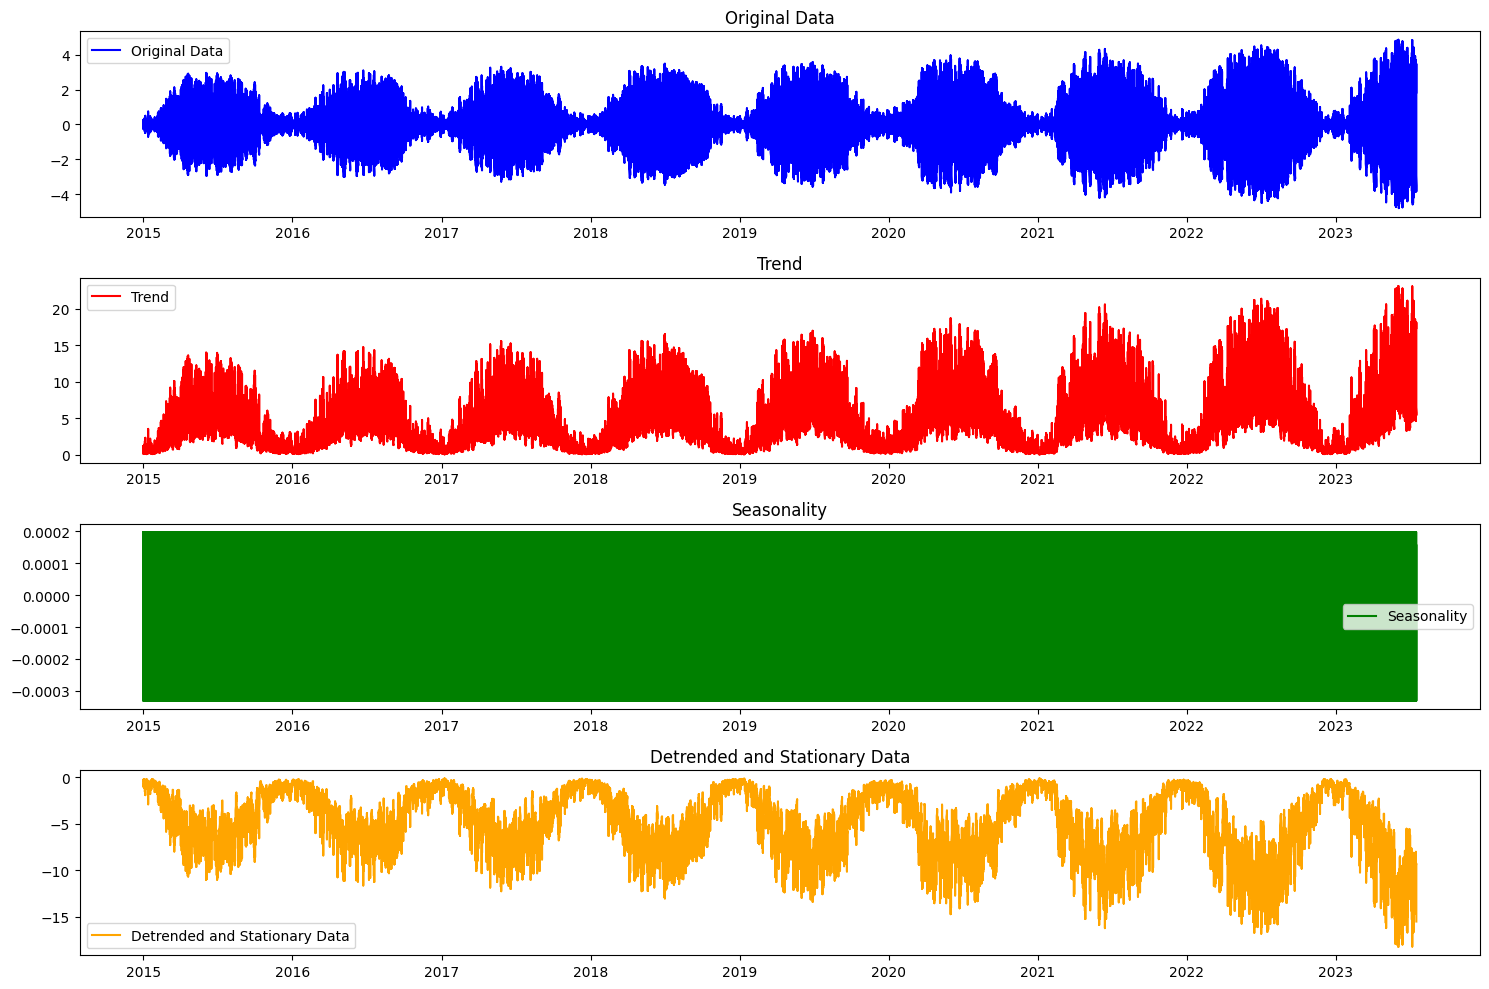

Epoch 1/10
19967/19967 [==============================] - 41s 2ms/step - loss: 7.7348e-04 - val_loss: nan
Epoch 2/10
19967/19967 [==============================] - 40s 2ms/step - loss: 1.3838e-05 - val_loss: nan
Epoch 3/10
19967/19967 [==============================] - 42s 2ms/step - loss: 6.7544e-06 - val_loss: nan
Epoch 4/10
19967/19967 [==============================] - 40s 2ms/step - loss: 4.6638e-06 - val_loss: nan
Epoch 5/10
19967/19967 [==============================] - 40s 2ms/step - loss: 3.9840e-06 - val_loss: nan
Epoch 6/10
19967/19967 [==============================] - 42s 2ms/step - loss: 3.5667e-06 - val_loss: nan
Epoch 7/10
19967/19967 [==============================] - 43s 2ms/step - loss: 3.2188e-06 - val_loss: nan
Epoch 8/10
19967/19967 [==============================] - 43s 2ms/step - loss: 3.0212e-06 - val_loss: nan
Epoch 9/10
19967/19967 [==============================] - 47s 2ms/step - loss: 2.8595e-06 - val_loss: nan
Epoch 10/10
469/469 [=========================

ValueError: Input contains NaN.

In [451]:
# Choose the target variable for forecasting
target = 'Solar_gwh'
preprocessed_data = preprocess_data(data_df, target, freq=None, rolling_mean=5, detrend=True)
# Perform LSTM forecasting on the preprocessed data
forecast_results = lstm_model_seasnol(preprocessed_data, target, lookback=5)

In [ ]:
# Assuming 'data_df' is your input DataFrame containing the processing data
# Set detrend=True and sampling_frequency (set to None) as follows:
results = lstm_model('Wind_offshore_gwh', data_df, lookback=12, sampling_frequency=None, rolling_mean=None, detrend=True, moving_average=False)


Epoch 1/100
1997/1997 [==============================] - 11s 5ms/step - loss: 0.0015 - val_loss: 1.9164e-04
Epoch 2/100
1997/1997 [==============================] - 9s 5ms/step - loss: 6.6375e-05 - val_loss: 8.4271e-05
Epoch 3/100
1997/1997 [==============================] - 9s 5ms/step - loss: 3.1140e-05 - val_loss: 3.1846e-05
Epoch 4/100
1997/1997 [==============================] - 10s 5ms/step - loss: 1.5269e-05 - val_loss: 1.2373e-05
Epoch 5/100
1997/1997 [==============================] - 10s 5ms/step - loss: 1.0831e-05 - val_loss: 1.3922e-05
Epoch 6/100
1997/1997 [==============================] - 10s 5ms/step - loss: 7.5163e-06 - val_loss: 7.1326e-06
Epoch 7/100
1997/1997 [==============================] - 9s 5ms/step - loss: 5.6507e-06 - val_loss: 7.6637e-06
Epoch 8/100
1997/1997 [==============================] - 9s 5ms/step - loss: 4.5517e-06 - val_loss: 8.0398e-06
Epoch 9/100
1997/1997 [==============================] - 9s 5ms/step - loss: 4.0779e-06 - val_loss: 6.3344e-06
E

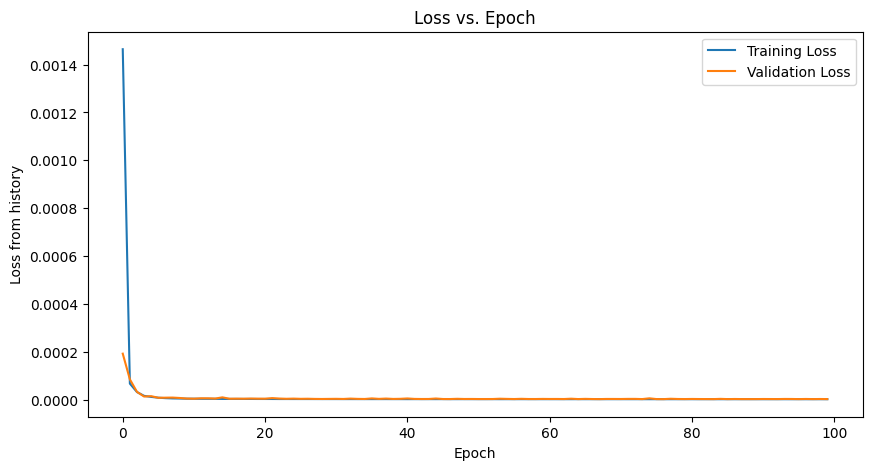

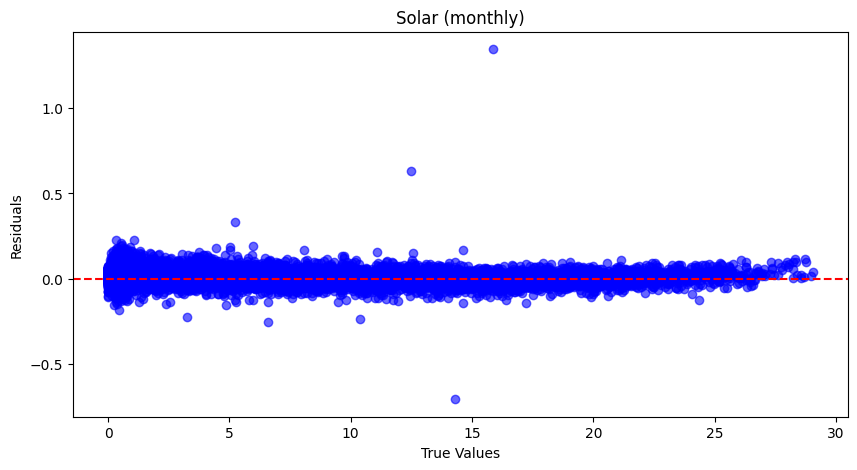

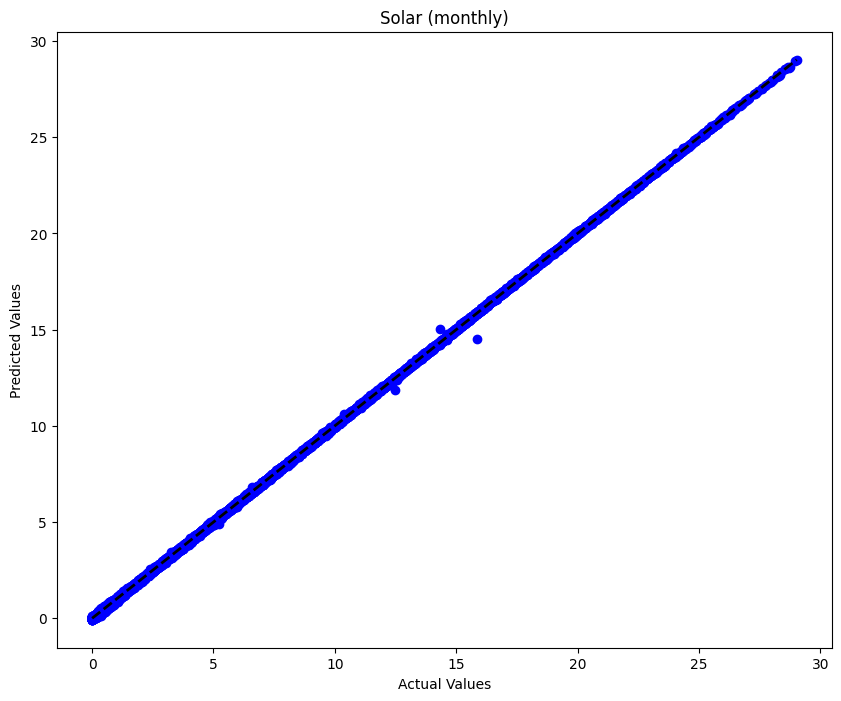

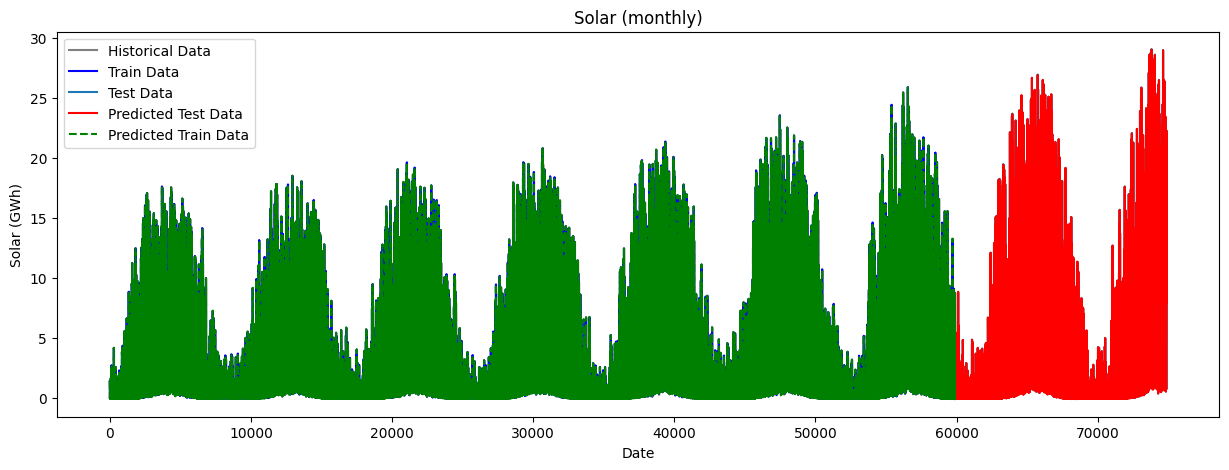

Train RMSE: 0.029625724605977656
Train MSE: 0.00087768355842923
Train MAE: 0.021974759660319577
Train R2 Score: 0.9999624258864435
Test RMSE: 0.0386343872354141
Test MSE: 0.0014926158770559278
Test MAE: 0.026595514073736205
Test R2 Score: 0.9999656079221069
X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, dfs_resampled.shape = (59893, 12, 1) (14986, 12, 1) (59893, 1) (14986, 1) (74867, 12, 1) (74867, 1) (74879, 33)


In [435]:
# Assuming 'data_df' is your input DataFrame containing the processing data
# Set rolling_mean and sampling_frequency (set to None) as follows:
results = lstm_model_fancy('Solar_gwh', data_df, lookback=12, sampling_frequency=None, rolling_mean=12, detrend=False, moving_average=False)

Epoch 1/100


/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_74360/3998490672.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs['Date'] = pd.to_datetime(dfs['Date'])


3/3 [==============================] - 1s 89ms/step - loss: 0.2586 - val_loss: 0.3262
Epoch 2/100
3/3 [==============================] - 0s 13ms/step - loss: 0.2332 - val_loss: 0.2904
Epoch 3/100
3/3 [==============================] - 0s 11ms/step - loss: 0.2055 - val_loss: 0.2478
Epoch 4/100
3/3 [==============================] - 0s 11ms/step - loss: 0.1732 - val_loss: 0.1982
Epoch 5/100
3/3 [==============================] - 0s 11ms/step - loss: 0.1353 - val_loss: 0.1406
Epoch 6/100
3/3 [==============================] - 0s 10ms/step - loss: 0.0908 - val_loss: 0.0810
Epoch 7/100
3/3 [==============================] - 0s 10ms/step - loss: 0.0502 - val_loss: 0.0514
Epoch 8/100
3/3 [==============================] - 0s 10ms/step - loss: 0.0382 - val_loss: 0.0930
Epoch 9/100
3/3 [==============================] - 0s 10ms/step - loss: 0.0536 - val_loss: 0.0716
Epoch 10/100
3/3 [==============================] - 0s 10ms/step - loss: 0.0382 - val_loss: 0.0529
Epoch 11/100
3/3 [=============

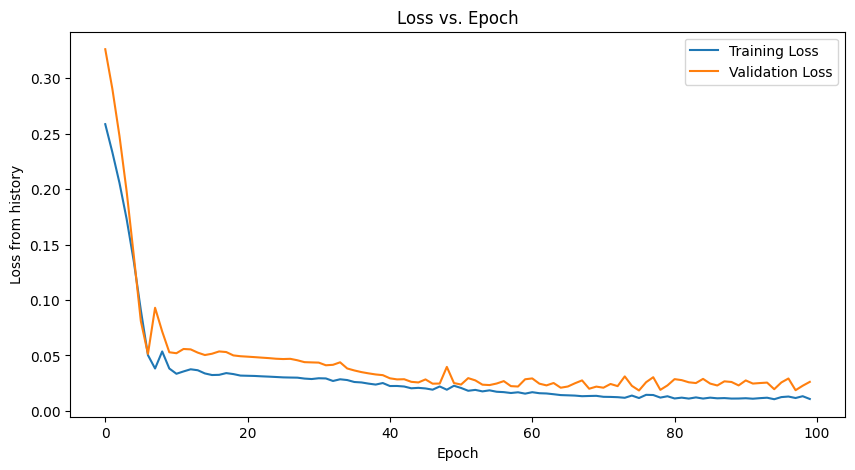

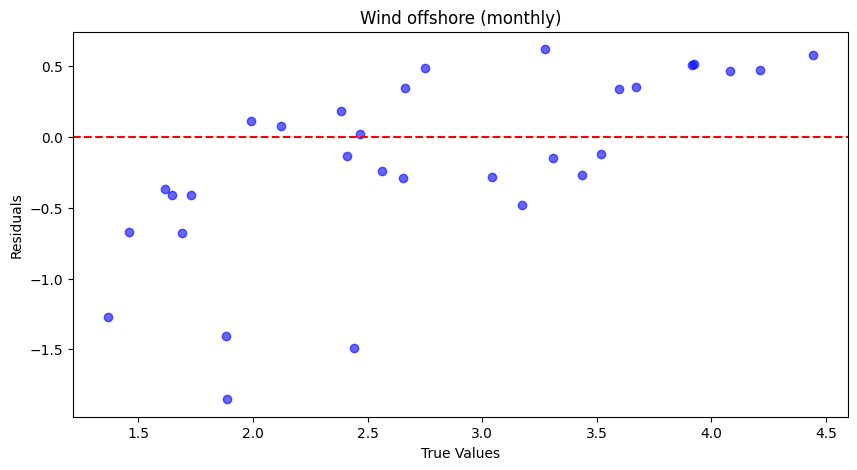

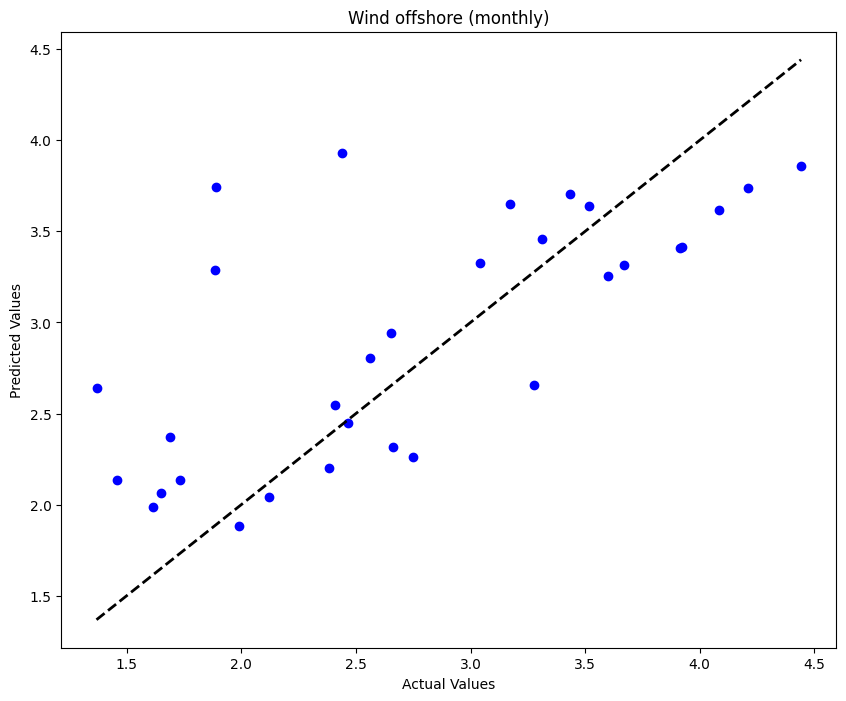

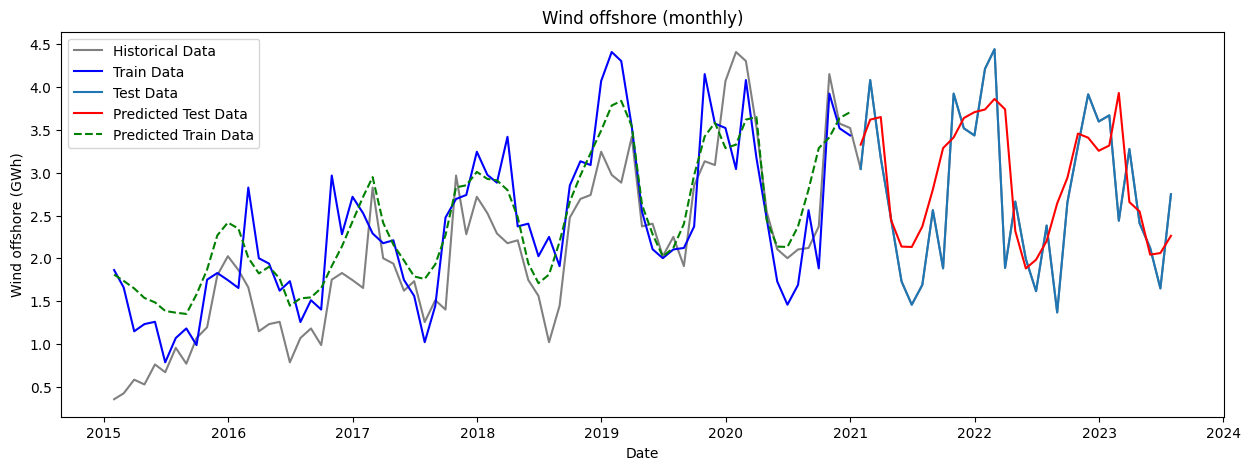

Train RMSE: 0.42722474839627905
Train MSE: 0.18252098564226393
Train MAE: 0.3323982420407303
Train R2 Score: 0.7667429659213647
Test RMSE: 0.6609536335516458
Test MSE: 0.4368597057051233
Test MAE: 0.5031796856487122
Test R2 Score: 0.43957872295300704
X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, dfs_resampled.shape = (72, 12, 1) (31, 12, 1) (72, 1) (31, 1) (91, 12, 1) (91, 1) (103, 1)


In [433]:
# Assuming 'data_df' is your input DataFrame containing the processing data
results = lstm_model('Wind_offshore_gwh', data_df, lookback=12, sampling_frequency='M')
#results = lstm_model('Total_other_renewable_gwh', data_df, lookback=12, sampling_frequency='D')

Epoch 1/100
1996/1996 [==============================] - 23s 11ms/step - loss: 0.0034 - val_loss: 0.0016
Epoch 2/100
1996/1996 [==============================] - 21s 10ms/step - loss: 8.1080e-04 - val_loss: 0.0015
Epoch 3/100
1996/1996 [==============================] - 21s 11ms/step - loss: 7.8109e-04 - val_loss: 0.0017
Epoch 4/100
1996/1996 [==============================] - 22s 11ms/step - loss: 7.6418e-04 - val_loss: 0.0015
Epoch 5/100
1996/1996 [==============================] - 21s 11ms/step - loss: 7.4540e-04 - val_loss: 0.0015
Epoch 6/100
1996/1996 [==============================] - 22s 11ms/step - loss: 7.3592e-04 - val_loss: 0.0015
Epoch 7/100
1996/1996 [==============================] - 22s 11ms/step - loss: 7.3245e-04 - val_loss: 0.0016
Epoch 8/100
1996/1996 [==============================] - 21s 10ms/step - loss: 7.2744e-04 - val_loss: 0.0016
Epoch 9/100
1996/1996 [==============================] - 21s 11ms/step - loss: 7.2664e-04 - val_loss: 0.0015
Epoch 10/100
1996/1996 

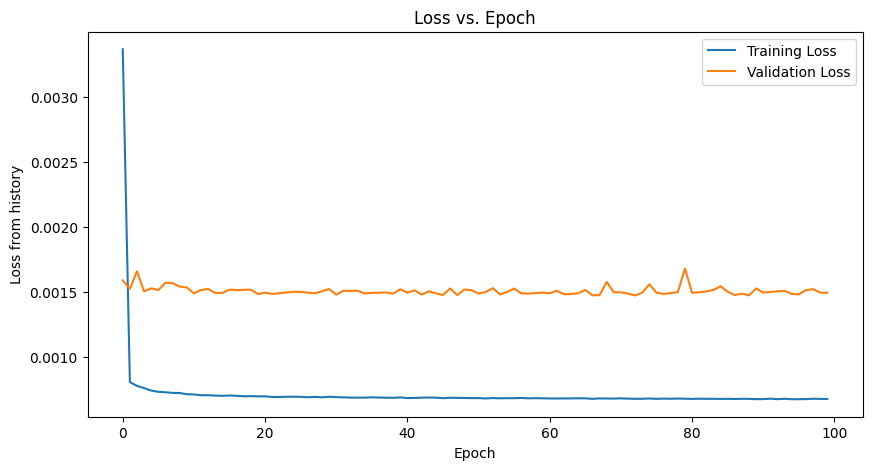

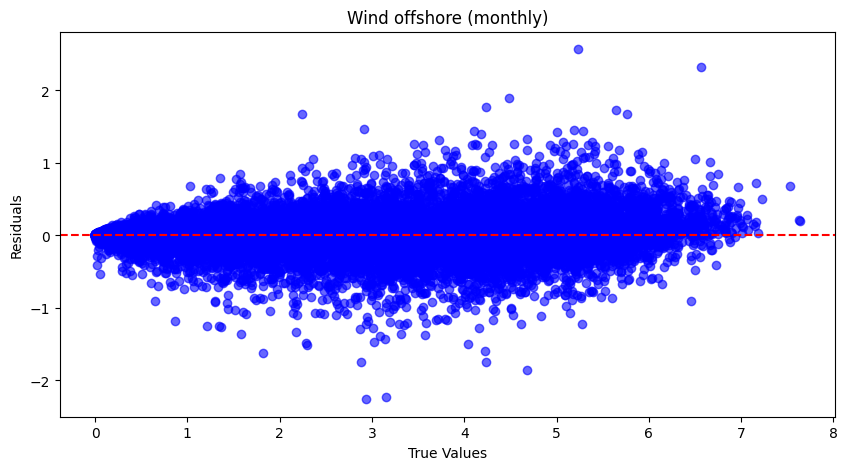

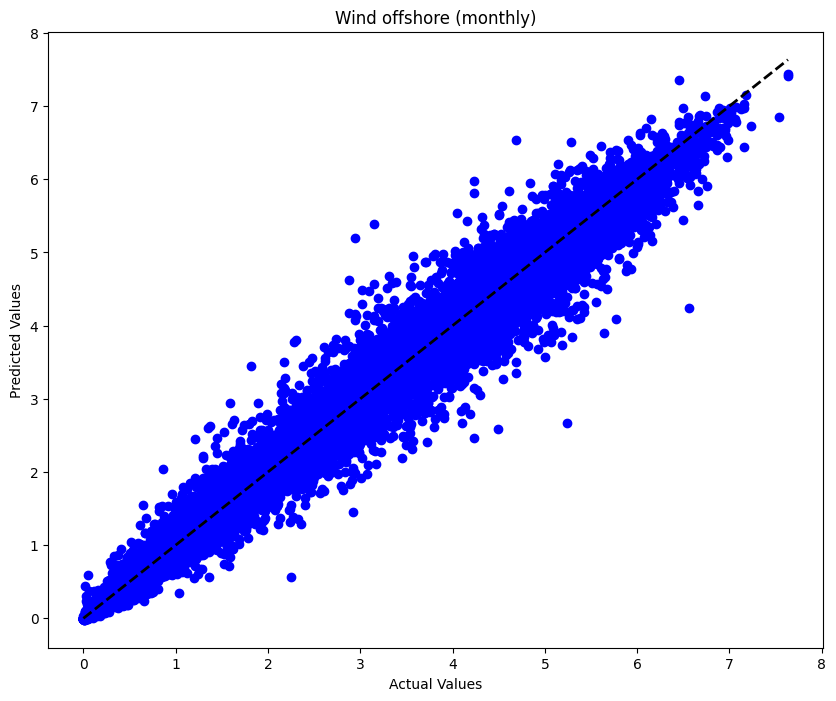

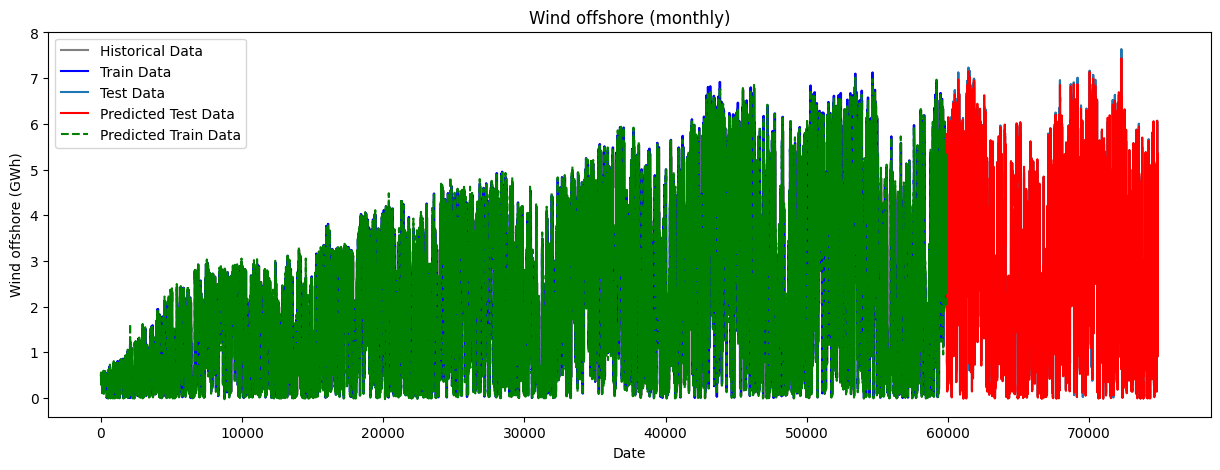

Train RMSE: 0.19774090721252052
Train MSE: 0.03910146638523065
Train MAE: 0.12786815166535231
Train R2 Score: 0.9862060659075607
Test RMSE: 0.2952551492739343
Test MSE: 0.08717560317277324
Test MAE: 0.2038663594773823
Test R2 Score: 0.975294625512996
X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, dfs_resampled.shape = (59879, 30, 1) (15000, 30, 1) (59879, 1) (15000, 1) (74849, 30, 1) (74849, 1) (74879, 33)


In [453]:
results = lstm_model('Wind_offshore_gwh', data_df, lookback=30, sampling_frequency=None)

/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_74360/3998490672.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs['Date'] = pd.to_datetime(dfs['Date'])


Epoch 1/100
83/83 [==============================] - 2s 9ms/step - loss: 0.0537 - val_loss: 0.0545
Epoch 2/100
83/83 [==============================] - 0s 6ms/step - loss: 0.0382 - val_loss: 0.0520
Epoch 3/100
83/83 [==============================] - 0s 6ms/step - loss: 0.0366 - val_loss: 0.0504
Epoch 4/100
83/83 [==============================] - 0s 6ms/step - loss: 0.0353 - val_loss: 0.0474
Epoch 5/100
83/83 [==============================] - 0s 6ms/step - loss: 0.0324 - val_loss: 0.0422
Epoch 6/100
83/83 [==============================] - 0s 6ms/step - loss: 0.0304 - val_loss: 0.0405
Epoch 7/100
83/83 [==============================] - 0s 6ms/step - loss: 0.0296 - val_loss: 0.0402
Epoch 8/100
83/83 [==============================] - 0s 6ms/step - loss: 0.0282 - val_loss: 0.0394
Epoch 9/100
83/83 [==============================] - 0s 6ms/step - loss: 0.0277 - val_loss: 0.0417
Epoch 10/100
83/83 [==============================] - 0s 6ms/step - loss: 0.0277 - val_loss: 0.0404
Epoch 11/

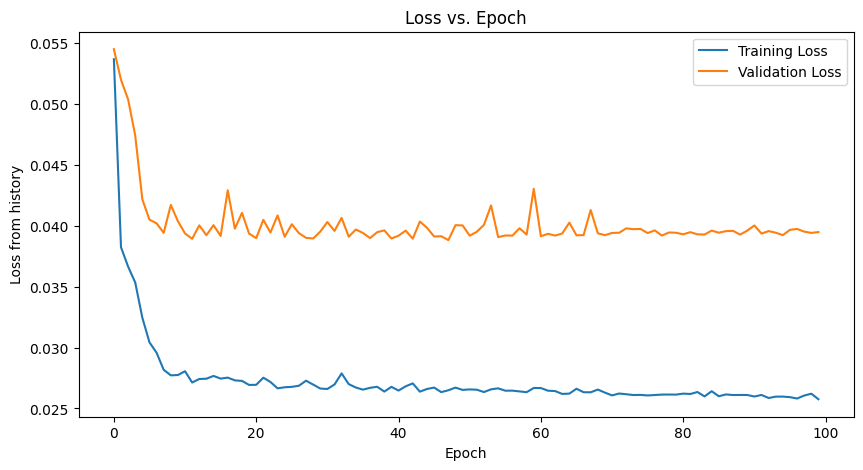

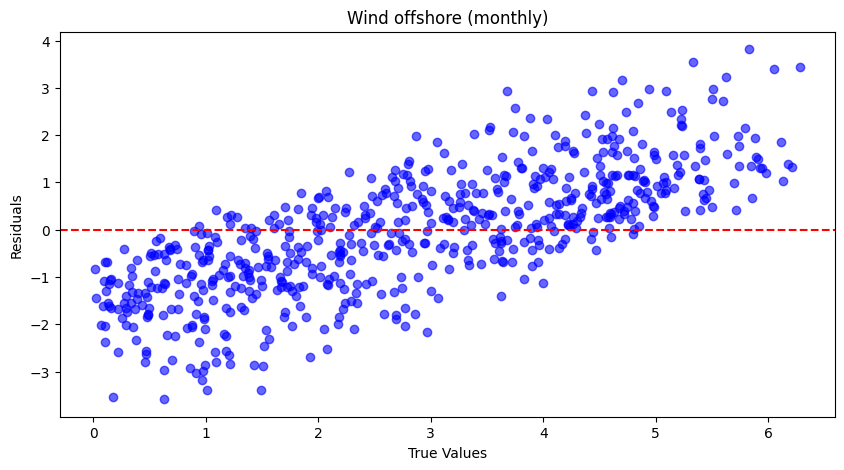

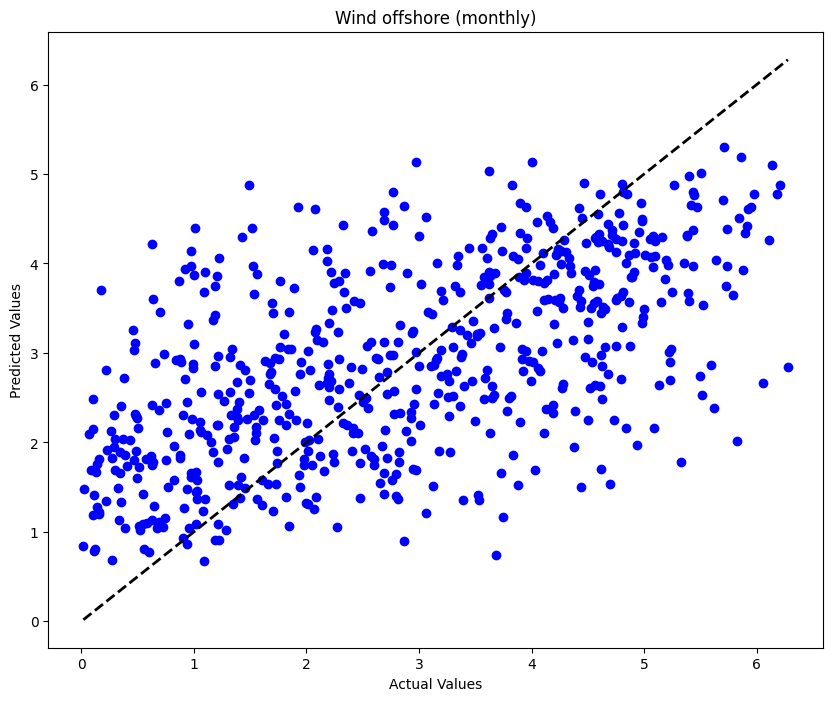

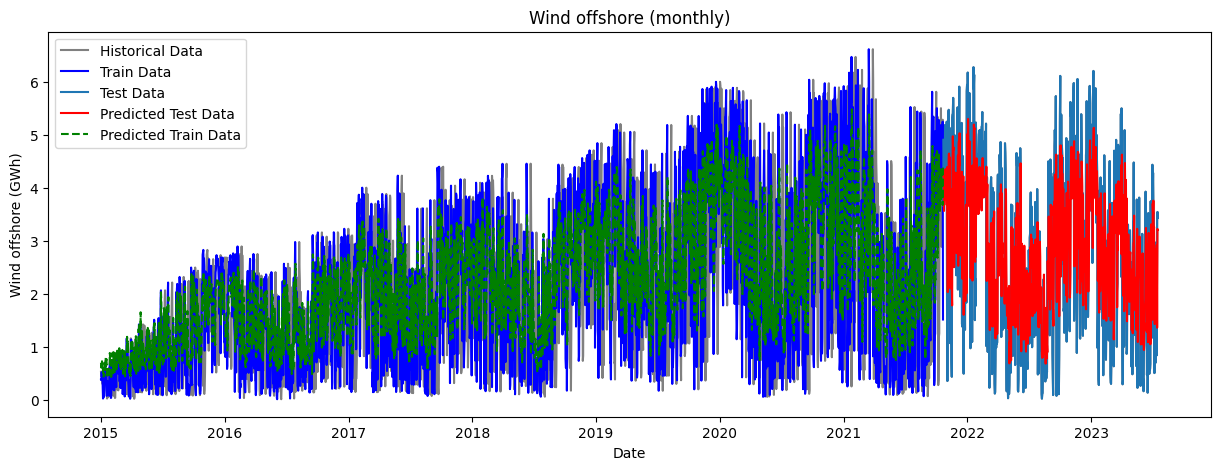

Train RMSE: 1.0595342362016684
Train MSE: 1.122612797683453
Train MAE: 0.8373156517966284
Train R2 Score: 0.5121002413096107
Test RMSE: 1.3135060777049594
Test MSE: 1.7252982161678667
Test MAE: 1.0544339950392219
Test R2 Score: 0.35214255111597625
X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, dfs_resampled.shape = (2486, 12, 1) (634, 12, 1) (2486, 1) (634, 1) (3108, 12, 1) (3108, 1) (3120, 1)


In [430]:
# Assuming 'data_df' is your input DataFrame containing the processing data
results = lstm_model('Wind_offshore_gwh', data_df, lookback=12, sampling_frequency='D')

## Multivariate LSTM forecasting

#### correct code 

In [ ]:
def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback, :-1])
        y.append(data[i+lookback, -1])
    return np.array(X), np.array(y)

def lstm_mlvrt(target, data_df, features, lookback=12, sampling_frequency='M', rolling_mean=None, detrend=False, moving_average=False, ma_window=None):
    # Prepare the input data
    target_label = target.replace('_gwh', ' (GWh)').replace('_', ' ')
    main_target = target.replace('_', ' ').replace('gwh', '(monthly)')
    
    if sampling_frequency:
        data_df['Date'] = pd.to_datetime(data_df['Date'])
        data_df.set_index('Date', inplace=True)
        dfs_resampled = data_df[features + [target]].resample(sampling_frequency).mean()
    else:
        dfs_resampled = data_df[features + [target]]
    
    if rolling_mean:
        for feature in features + [target]:
            dfs_resampled[feature] = dfs_resampled[feature].rolling(window=rolling_mean, min_periods=1, center=True).mean()
            dfs_resampled[feature] = dfs_resampled[feature].fillna(method='bfill')
    
    if detrend:
        result = seasonal_decompose(dfs_resampled[target], model='additive', period=12)
        dfs_resampled[target] = dfs_resampled[target] - result.trend
        dfs_resampled[target] = dfs_resampled[target].fillna(method='bfill')
    
    if moving_average:
        for feature in features + [target]:
            dfs_resampled[feature] = dfs_resampled[feature].rolling(window=ma_window, min_periods=1, center=True).mean()
            dfs_resampled[feature] = dfs_resampled[feature].fillna(method='bfill')
    
    scaler = MinMaxScaler(feature_range=(0, 1))
    data_scaled = scaler.fit_transform(dfs_resampled.values)
    
    X_lstm, y_lstm = create_sequences(data_scaled, lookback)
    
    # Set the train-test split to be 80-20%
    train_size = int(len(X_lstm) * 0.8)
    X_train_lstm, X_test_lstm = X_lstm[:train_size], X_lstm[train_size-lookback:]
    y_train_lstm, y_test_lstm = y_lstm[:train_size], y_lstm[train_size-lookback:]
    
    # Build the LSTM model
    model = Sequential()
    model.add(LSTM(units=64, activation='relu', input_shape=(lookback, len(features)), return_sequences=True))
    model.add(LSTM(units=32, activation='relu'))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(X_train_lstm, y_train_lstm, epochs=30, batch_size=5, validation_data=(X_test_lstm, y_test_lstm), verbose=1)
    
    # LSTM prediction on test and train data
    y_pred_train_lstm = model.predict(X_train_lstm)
    y_pred_test_lstm = model.predict(X_test_lstm)
    
    # Inverse transform the scaled data to get the original scale
    y_pred_train_lstm = scaler.inverse_transform(np.hstack((X_train_lstm[:, -1, :], y_pred_train_lstm)))
    y_pred_test_lstm = scaler.inverse_transform(np.hstack((X_test_lstm[:, -1, :], y_pred_test_lstm)))
    y_train_lstm = scaler.inverse_transform(np.hstack((X_train_lstm[:, -1, :], y_train_lstm.reshape(-1, 1))))
    y_test_lstm = scaler.inverse_transform(np.hstack((X_test_lstm[:, -1, :], y_test_lstm.reshape(-1, 1))))
    
    # Compute metrics for LSTM
    train_rmse = np.sqrt(mean_squared_error(y_train_lstm[:, -1], y_pred_train_lstm[:, -1]))
    test_rmse = np.sqrt(mean_squared_error(y_test_lstm[:, -1], y_pred_test_lstm[:, -1]))
    train_mse = mean_squared_error(y_train_lstm[:, -1], y_pred_train_lstm[:, -1])
    test_mse = mean_squared_error(y_test_lstm[:, -1], y_pred_test_lstm[:, -1])
    train_mae = mean_absolute_error(y_train_lstm[:, -1], y_pred_train_lstm[:, -1])
    test_mae = mean_absolute_error(y_test_lstm[:, -1], y_pred_test_lstm[:, -1])
    train_r2 = r2_score(y_train_lstm[:, -1], y_pred_train_lstm[:, -1])
    test_r2 = r2_score(y_test_lstm[:, -1], y_pred_test_lstm[:, -1])
    
    # Calculate residuals
    residuals = y_test_lstm[:, -1] - y_pred_test_lstm[:, -1]

    print("Train RMSE:", train_rmse)
    print("Train MSE:", train_mse)
    print("Train MAE:", train_mae)
    print("Train R2 Score:", train_r2)
    print("Test RMSE:", test_rmse)
    print("Test MSE:", test_mse)
    print("Test MAE:", test_mae)
    print("Test R2 Score:", test_r2)

    # Plot loss versus epoch and validation loss versus epoch
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss from history')
    plt.title('Loss vs. Epoch')
    plt.legend()
    plt.show()
    
    # Create a residual plot
    plt.figure(figsize=(10, 5))
    plt.scatter(y_test_lstm[:, -1], residuals, color='blue', alpha=0.6)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.xlabel('True Values')
    plt.ylabel('Residuals')
    plt.title(main_target)
    plt.show()
    
    # Plot actual vs. predicted values
    plt.figure(figsize=(10, 8))
    plt.scatter(y_test_lstm[:, -1], y_pred_test_lstm[:, -1], label='', color='blue')
    plt.plot([y_test_lstm[:, -1].min(), y_test_lstm[:, -1].max()], [y_test_lstm[:, -1].min(), y_test_lstm[:, -1].max()], 'k--', lw=2, label='')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(main_target)
    plt.show()
    
    # Plot actual, train data, and predicted test data for LSTM
    plt.figure(figsize=(15, 5))
    train_index = dfs_resampled.index[:train_size][-len(y_train_lstm):]
    test_index = dfs_resampled.index[-len(y_test_lstm):]  # Ensure test_index and y_test_lstm have the same length
    plt.plot(dfs_resampled.index, dfs_resampled[target], label='Historical Data', color='gray')
    plt.plot(train_index, y_train_lstm[:, -1], label='Train Data', color='blue')
    plt.plot(test_index, y_test_lstm[:, -1], label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm[:, -1], label='Predicted Test Data', color='red')
    plt.plot(train_index, y_pred_train_lstm[:, -1], label='Predicted Train Data', color='green', linestyle='dashed')
    # Draw a vertical line between train and test split
    plt.axvline(train_index[-1], color='k', linestyle='--')
    plt.legend()
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.show()

    #print('X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, dfs_resampled.shape =', X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, dfs_resampled.shape)

    return {
        'train_rmse': train_rmse,
        'train_mse': train_mse,
        'train_mae': train_mae,
        'train_r2': train_r2,
        'test_rmse': test_rmse,
        'test_mse': test_mse,
        'test_mae': test_mae,
        'test_r2': test_r2,
        'residuals': residuals,
        'y_test_predicted': y_pred_test_lstm,
        'model': model,
        'X_train_lstm': X_train_lstm,
        'X_test_lstm': X_test_lstm
    }


/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_74360/2016987420.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs_resampled[feature] = dfs_resampled[feature].rolling(window=rolling_mean, min_periods=1, center=True).mean()
/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_74360/2016987420.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs_resampled[feature] = dfs_resampled[feature].fillna(method='bfill')


Epoch 1/30
11976/11976 [==============================] - 96s 8ms/step - loss: 0.0155 - val_loss: 0.0227
Epoch 2/30
11976/11976 [==============================] - 105s 9ms/step - loss: 0.0145 - val_loss: 0.0227
Epoch 3/30
11976/11976 [==============================] - 104s 9ms/step - loss: 0.0141 - val_loss: 0.0264
Epoch 4/30
11976/11976 [==============================] - 96s 8ms/step - loss: 0.0139 - val_loss: 0.0211
Epoch 5/30
11976/11976 [==============================] - 96s 8ms/step - loss: 0.0136 - val_loss: 0.0241
Epoch 6/30
11976/11976 [==============================] - 103s 9ms/step - loss: 0.0133 - val_loss: 0.0190
Epoch 7/30
11976/11976 [==============================] - 99s 8ms/step - loss: 0.0131 - val_loss: 0.0213
Epoch 8/30
11976/11976 [==============================] - 102s 8ms/step - loss: 0.0129 - val_loss: 0.0253
Epoch 9/30
11976/11976 [==============================] - 100s 8ms/step - loss: 0.0126 - val_loss: 0.0216
Epoch 10/30
11976/11976 [=========================

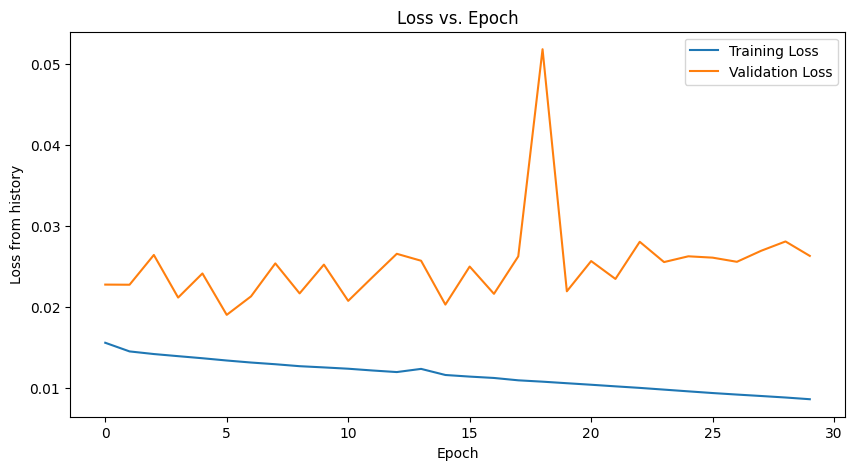

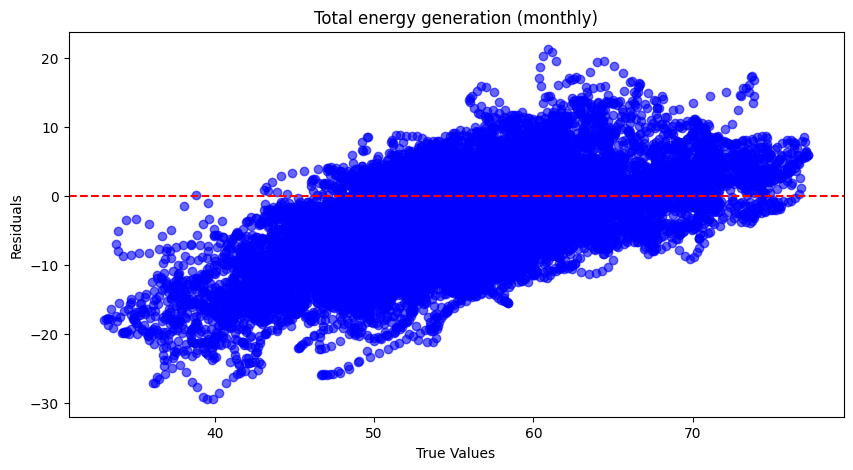

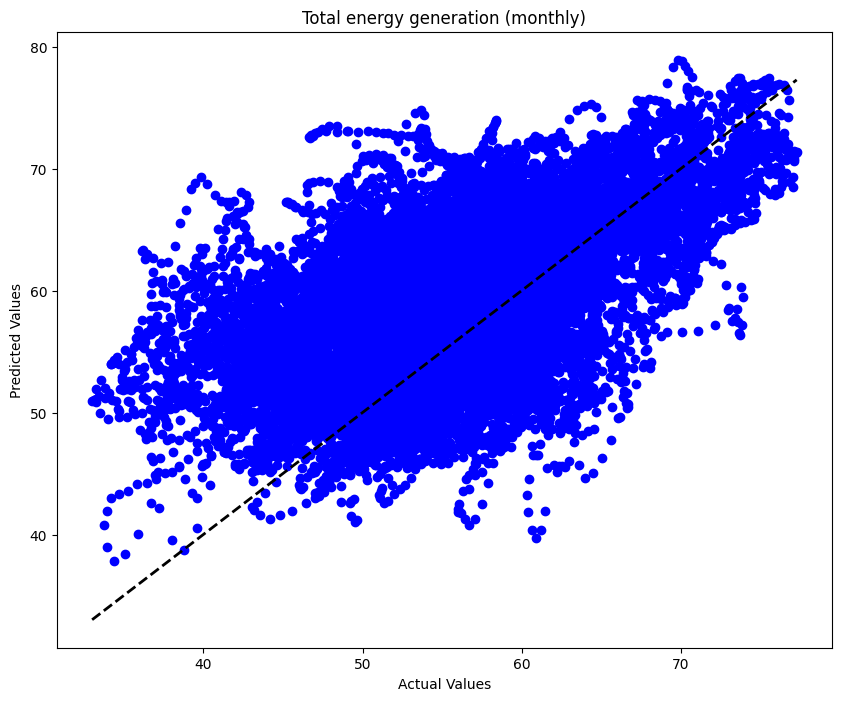

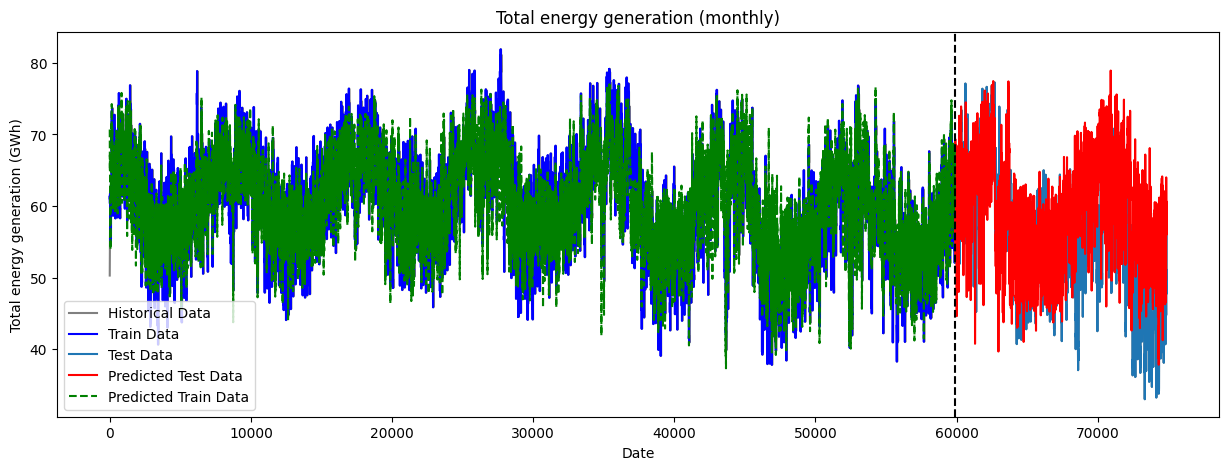

In [567]:
target = 'Total_energy_generation_gwh'
features = ['Solar_gwh', 'Wind_onshore_gwh', 'Wind_offshore_gwh']  # You can add other features if needed
result = lstm_mlvrt(target, data, features=features, lookback=30, sampling_frequency=None,
                    rolling_mean=30, detrend=False, moving_average=False, ma_window=None)

#### Fetuare importnce 

In [ ]:
#pip install shap

In [ ]:
import shap
def extract_feature_importance_lstm(model, X_train, X_test):
    # Create a SHAP explainer for the LSTM model
    explainer = shap.Explainer(model)

    # Compute SHAP values for the test data
    shap_values = explainer.shap_values(X_test)

    # Plot feature importance using summary_plot
    shap.summary_plot(shap_values, X_test, plot_type='bar')

    # Return SHAP values for further analysis if needed
    return shap_values

In [ ]:
def lstm_model_fancy(target, data_df, features, lookback=12, sampling_frequency='M', rolling_mean=None, detrend=False, moving_average=False, ma_window=None):
    #return model, X_train_lstm, X_test_lstm

In [ ]:

# Train the LSTM model and get the model object and data
model, X_train_lstm, X_test_lstm = lstm_model_fancy(target=, data_df=data_df, features, lookback=12, sampling_frequency='M', rolling_mean=None, detrend=False, moving_average=False, ma_window=None)
# Call the extract_feature_importance_lstm function
shap_values = extract_feature_importance_lstm(model, X_train_lstm, X_test_lstm)

In [378]:
features= ['Date', 'Solar_gwh', 'Total_other_renewable_gwh']#
#Other potential target 
#'Wind_onshore_gwh', Wind_offshore_gwh', 'Other_renewable_gwh', 'Total_other_renewable_gwh'

In [280]:
#target = 'Total_energy_generation_gwh'
#dfs = data_df[['Date', 'Solar_gwh', 'Total_other_renewable_gwh',target]]
#dfs.head()

In [281]:
columns_to_keep = ['Date', 'Solar_gwh', 'Total_other_renewable_gwh','Total_energy_generation_gwh']
dfs = data_df[columns_to_keep].copy()
dfs.head()


,Date,Solar_gwh,Total_other_renewable_gwh,Total_energy_generation_gwh
0,2015-01-01,0.0,9.66900,51.45925
1,2015-01-01,0.0,9.86225,49.98825
2,2015-01-01,0.0,10.00325,49.26525
3,2015-01-01,0.0,9.97275,48.53800
4,2015-01-01,0.0,10.03125,48.63000


In [113]:
dfs.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
74874    False
74875    False
74876    False
74877    False
74878    False
Length: 74879, dtype: bool

## Fitting of raw data

In [ ]:
data_df.columns

In [381]:
columns_to_keep = ['Date', 'Solar_gwh', 'Total_other_renewable_gwh','Total_energy_generation_gwh']
dfs = data_df[columns_to_keep].copy()
dfs.head()

#data_df.head()

,Date,Solar_gwh,Total_other_renewable_gwh,Total_energy_generation_gwh
0,2015-01-01,0.0,9.66900,51.45925
1,2015-01-01,0.0,9.86225,49.98825
2,2015-01-01,0.0,10.00325,49.26525
3,2015-01-01,0.0,9.97275,48.53800
4,2015-01-01,0.0,10.03125,48.63000
